In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
import statsmodels.formula.api as smf

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

from sklearn.inspection import partial_dependence
from sklearn.inspection import PartialDependenceDisplay

from sklearn.tree import DecisionTreeClassifier, plot_tree
from statsmodels.nonparametric.smoothers_lowess import lowess
import statsmodels.api as sm

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

# Research Design

The aim of the empirical research is to determine whether the factors influencing the valuation and success probability of startups differ depending on the type of company (blockchain startups versus traditional IT companies), taking into account the venture-specific characteristics of each group.

## Research Hypotheses

H1. The determinants of startup valuation and success significantly differ across company types, specifically between blockchain startups and traditional IT firms.

H2. Non-financial metrics (e.g., Tone_Index, Has_Twitter, Has_GitHub) have a statistically significant impact not only on blockchain startups but also on traditional IT companies, particularly at early development stages. Consequently, we hypothesize that conventional valuation approaches, which rely exclusively on financial indicators, may be insufficient and should be revised to better reflect the dynamics of the digital economy.

## Sample Description and Data Sources

For the purpose of the empirical analysis, a sample of 1,000 startups was compiled, comprising both blockchain companies and traditional technology startups. All data were obtained from publicly available sources. The primary platforms used for data collection included ICObench, ICO Drops, Crunchbase, AngelList (Wellfound), and Kaggle (specifically, the Startups Crunchbase Investment dataset and Cryptocurrency ICO datasets).

## Sampling Strategy and Data Collection

The selection of traditional companies was guided by the principle of comparability with blockchain startups. Priority was given to early-stage IT firms operating in adjacent sectors (e.g., edtech and legaltech) and exhibiting similar digital characteristics, such as the presence of GitHub repositories. This approach ensured the relevance of the comparison and enabled a comprehensive analysis of the factors influencing market valuation and the probability of success, depending on the technological nature of the startup.

For blockchain startups, data were primarily gathered from ICObench and ICO Drops—platforms specializing in initial coin offerings (ICOs)—which provide project ratings, campaign timelines, team structures, and technological attributes. In addition, the Crunchbase database was utilized to obtain detailed information on both blockchain and traditional startups, including funding rounds, team composition, and market activity.

For traditional IT companies, data were collected from AngelList (Wellfound) and Crunchbase, allowing for the inclusion of startups operating in areas such as edtech, legaltech, SaaS, and other adjacent sectors. Public datasets from Kaggle were also employed, containing information on investment rounds, company development stages, and additional characteristics such as company age, presence of open-source repositories, and digital activity indicators.

## Variable Description and Operationalization

The dependent variable in this study is project success (Success), operationalized in a binary format. A value of 1 is assigned if the project has achieved key performance indicators relevant to its type, indicating successful outcomes. Otherwise, the variable takes the value of 0.

For blockchain startups, success is defined as the successful completion of an Initial Coin Offering (ICO)—specifically, meeting the stated fundraising targets, adhering to roadmap timelines, and launching a functioning product or platform. For traditional technology startups, success criteria include securing external funding (Seed, Series A or higher), reaching go-to-market status, or establishing a significant user base or commercial partnerships, as verified through publicly available sources such as Crunchbase, AngelList, and Kaggle. This operationalization enables the construction of a unified binary variable (Success) while preserving the substantive differences in capitalization and validation mechanisms across technological domains. 

The key independent variable is the type of company—classified as either a blockchain startup or a traditional technology firm. The model also includes a range of additional predictors that capture both internal characteristics of the startups and external market signals, enabling a comprehensive assessment of the factors influencing valuation and success likelihood.

# Data load

In [2]:
file_path = 'D:/final_blockchain_traditional/dataset.xlsx'

In [3]:
data = pd.read_excel(file_path)

In [4]:
data.head()

,Type,Success,Valuation_USD,Team_Size,Has_Twitter,Has_GitHub,Tone_Index,Uncertainty_Index,Founders_Experience,Business_Model_Clarity,Pitch_Quality_Score,KPI_Shared
0,traditional,1,382968.457660,13,0,0,0.750349,0.148461,19,4,2,0
1,blockchain,1,673236.867589,10,1,1,0.349025,0.234473,8,1,4,0
2,blockchain,1,722029.234416,9,1,1,0.227092,0.365373,12,5,4,1
3,traditional,1,421557.397663,13,0,0,0.729021,0.196762,0,5,1,1
4,blockchain,1,154882.986344,11,1,0,0.503370,0.157779,5,4,4,1


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Type                    1000 non-null   object 
 1   Success                 1000 non-null   int64  
 2   Valuation_USD           1000 non-null   float64
 3   Team_Size               1000 non-null   int64  
 4   Has_Twitter             1000 non-null   int64  
 5   Has_GitHub              1000 non-null   int64  
 6   Tone_Index              1000 non-null   float64
 7   Uncertainty_Index       1000 non-null   float64
 8   Founders_Experience     1000 non-null   int64  
 9   Business_Model_Clarity  1000 non-null   int64  
 10  Pitch_Quality_Score     1000 non-null   int64  
 11  KPI_Shared              1000 non-null   int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 93.9+ KB


## Variables and Their Characteristics

| **Variable**               | **Data Type**           | **Description**                                                                                                           |
|----------------------------|-------------------------|---------------------------------------------------------------------------------------------------------------------------|
| `Success`                  | Binary (0/1)            | Project success (successful ICO or go-to-market entry)                                                                   |
| `Valuation_USD`           | Numeric (USD)           | Market valuation of the company                                                                                           |
| `Team_Size`               | Numeric                 | Total number of team members                                                                                              |
| `Has_Twitter`             | Boolean (0/1)           | Presence of an active Twitter profile                                                                                     |
| `Has_GitHub`              | Boolean (0/1)           | Presence of a public code repository (e.g., GitHub), as a proxy for openness and community engagement                    |
| `Tone_Index`              | Numeric (0–1)           | Positivity index of project description or whitepaper (calculated using NLP techniques)                                  |
| `Uncertainty_Index`       | Numeric (0–1)           | Index of textual vagueness or ambiguity (calculated using NLP)                                                           |
| `Founders_Experience`     | Numeric (in years)      | Average experience of founders in entrepreneurship, IT, or venture capital                                               |
| `Business_Model_Clarity`  | Ordinal (1–5)           | Clarity and coherence of the business model description                                                                   |
| `Pitch_Quality_Score`     | Ordinal (1–5)           | Quality of the pitch presentation (visual design, structure, conciseness, etc.)                                           |
| `KPI_Shared`              | Boolean (0/1)           | Whether key performance metrics (e.g., MRR, DAU, growth) are publicly shared                                              |

# Descriptive statistics

The descriptive statistics are considered as follows. 

In [6]:
data.describe()

,Success,Valuation_USD,Team_Size,Has_Twitter,Has_GitHub,Tone_Index,Uncertainty_Index,Founders_Experience,Business_Model_Clarity,Pitch_Quality_Score,KPI_Shared
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,0.88600,505682.496905,9.945000,0.711000,0.632000,0.508203,0.278132,9.46500,3.022000,3.057000,0.601000
std,0.31797,156309.851108,3.175856,0.453525,0.482503,0.218027,0.162402,5.82724,1.394798,1.397034,0.489938
min,0.00000,-51077.006714,1.000000,0.000000,0.000000,0.005059,0.006860,0.00000,1.000000,1.000000,0.000000
25%,1.00000,400888.118126,8.000000,0.000000,0.000000,0.333674,0.150533,4.00000,2.000000,2.000000,0.000000
50%,1.00000,504882.842949,10.000000,1.000000,1.000000,0.517868,0.251864,9.00000,3.000000,3.000000,1.000000
75%,1.00000,609341.178648,12.000000,1.000000,1.000000,0.683106,0.383035,15.00000,4.000000,4.000000,1.000000
max,1.00000,994325.375146,23.000000,1.000000,1.000000,0.982640,0.841526,19.00000,5.000000,5.000000,1.000000


Let us visualize the data using graphs.

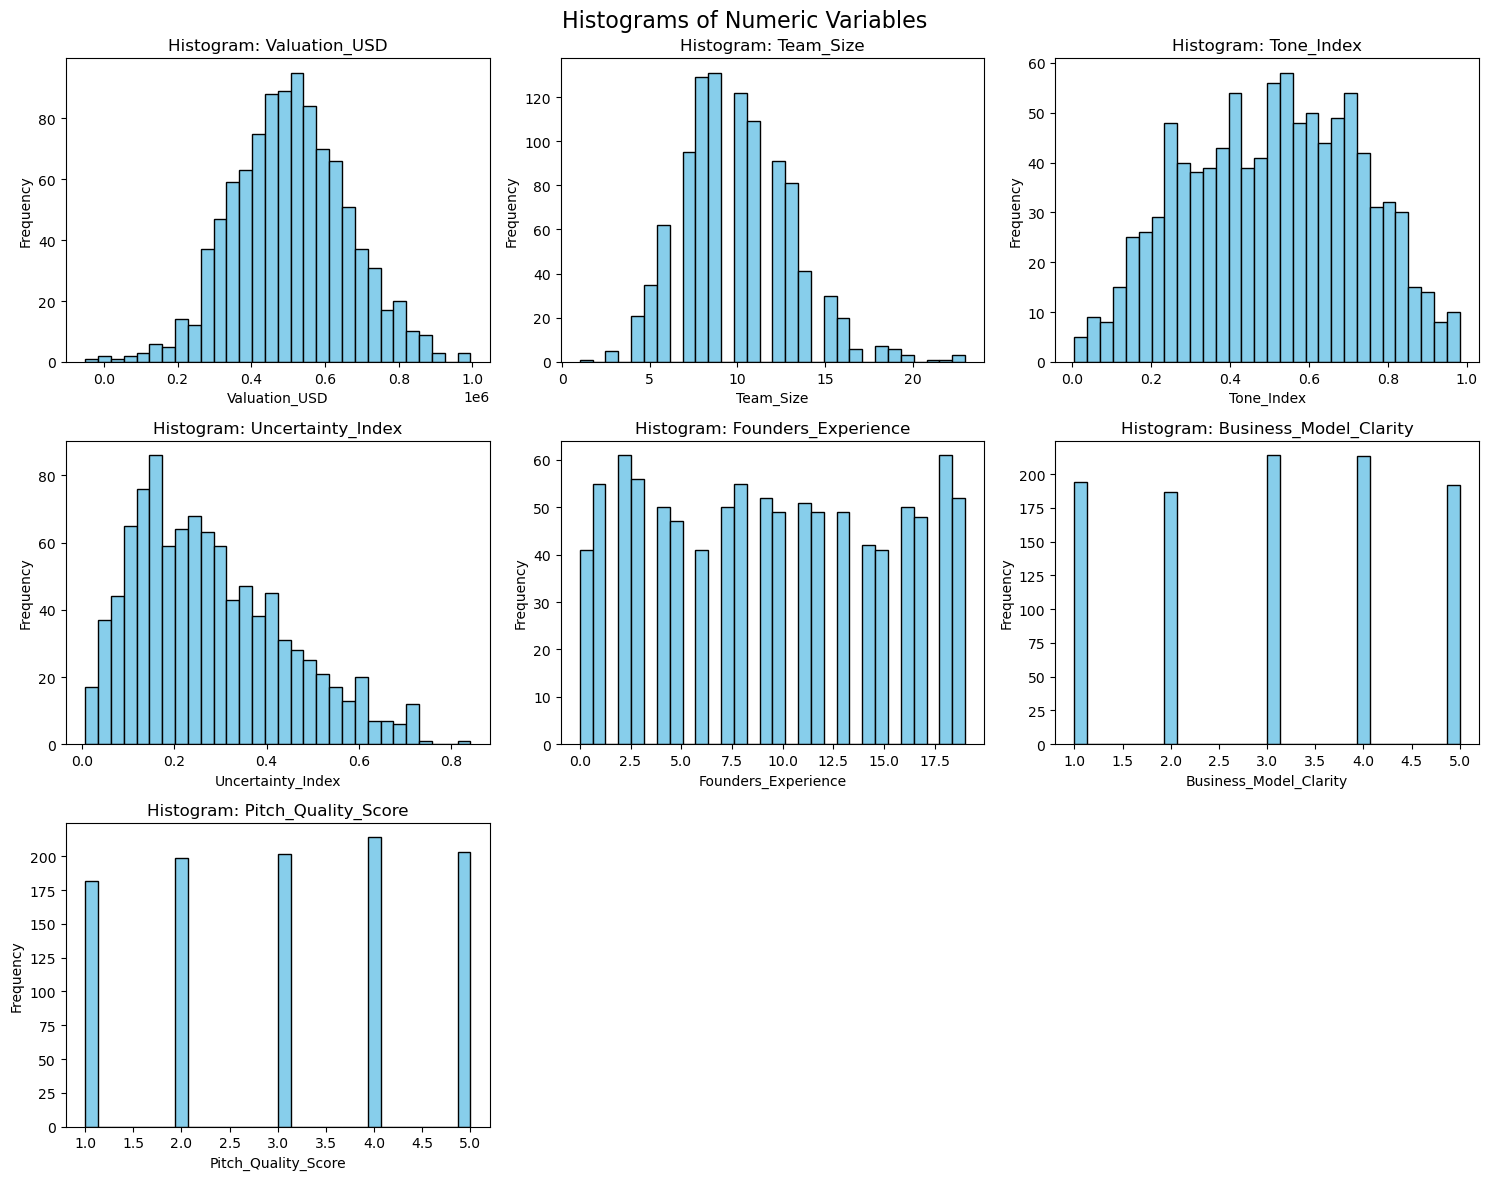

In [7]:
numeric_vars = [
    'Valuation_USD', 'Team_Size', 'Tone_Index', 'Uncertainty_Index',
    'Founders_Experience', 'Business_Model_Clarity', 'Pitch_Quality_Score'
]

fig, axs = plt.subplots(3, 3, figsize=(15, 12))
axs = axs.flatten()

for i, col in enumerate(numeric_vars):
    axs[i].hist(data[col], bins=30, color='skyblue', edgecolor='black')
    axs[i].set_title(f"Histogram: {col}")
    axs[i].set_xlabel(col)
    axs[i].set_ylabel("Frequency")

# Hide any unused subplots
for j in range(len(numeric_vars), len(axs)):
    axs[j].axis('off')

plt.suptitle("Histograms of Numeric Variables", fontsize=16)
plt.tight_layout()
plt.show()

Histograms of the main numerical variables in the dataset show that the variable **Valuation_USD** follows a normal distribution. The variable **Team_Size** is right-skewed, indicating that most teams are relatively small. The variables Tone_Index and Uncertainty_Index are bounded between 0 and 1 and exhibit moderate skewness. The variables **Founders_Experience** and **Pitch_Quality** appear to be mostly balanced or uniformly distributed across their respective ranges.

# Binary logistic regression with interactions

To test the research hypotheses, we applied quantitative analysis methods aimed at identifying differences in the factors influencing startup success depending on the type of company (blockchain vs. traditional technology firms). The primary analytical tool is binary logistic regression, which enables the estimation of the contribution of independent variables to the probability of a binary outcome—successful completion of an ICO (for blockchain startups) or achievement of comparable success indicators (for traditional startups). All numerical variables were standardized using z-transformation to enhance the interpretability of the coefficients and eliminate scale-related distortions.

To examine whether the significance of predictors varies by company type, we included **interaction terms** in the model. These reflect the interaction effects between the startup type and key characteristics (e.g., founders’ experience, pitch quality, presence on GitHub), allowing us to assess whether the predictors of success differ according to the technological nature of the startup.

## Logistic Regression Model

The binary logistic regression model used in the analysis is specified as follows:

$$
\text{logit}(P_i) = \ln\left(\frac{P_i}{1 - P_i}\right) = \beta_0 + \beta_1 \cdot X_{1i} + \beta_2 \cdot X_{2i} + \dots + \beta_k \cdot X_{ki} + \gamma_1 \cdot (X_{1i} \times T_i) + \dots + \gamma_m \cdot (X_{mi} \times T_i)
$$




**Where:**

- Pᵢ — probability of success for startup *i*  
- X₁ᵢ, ..., Xₖᵢ — independent variables (e.g., team size, tone index, founders' experience, etc.)  
- Tᵢ — binary variable indicating **startup type** (1 = blockchain, 0 = traditional IT company)  
- Xⱼ × Tᵢ — **interaction terms** between company type and selected predictors  
- β, γ — model coefficients to be estimated

In [8]:
df_interact = data.copy()

In [9]:
df_interact.head()

,Type,Success,Valuation_USD,Team_Size,Has_Twitter,Has_GitHub,Tone_Index,Uncertainty_Index,Founders_Experience,Business_Model_Clarity,Pitch_Quality_Score,KPI_Shared
0,traditional,1,382968.457660,13,0,0,0.750349,0.148461,19,4,2,0
1,blockchain,1,673236.867589,10,1,1,0.349025,0.234473,8,1,4,0
2,blockchain,1,722029.234416,9,1,1,0.227092,0.365373,12,5,4,1
3,traditional,1,421557.397663,13,0,0,0.729021,0.196762,0,5,1,1
4,blockchain,1,154882.986344,11,1,0,0.503370,0.157779,5,4,4,1


In [10]:
# Add binary encoding for 'Type'
df_interact['Type_bin'] = (df_interact['Type'] == 'blockchain').astype(int)

Перед запуском алгоритма нам нужно провести стандартизацию данных.

In [11]:
# List of numeric features to standardize
features_to_scale = [
    'Valuation_USD', 'Team_Size', 'Tone_Index', 'Uncertainty_Index',
    'Founders_Experience', 'Business_Model_Clarity', 'Pitch_Quality_Score'
]

# Apply .reshape(-1, 1).flatten() for each column
scaler = StandardScaler()
for col in features_to_scale:
    df_interact[col] = scaler.fit_transform(df_interact[col].values.reshape(-1, 1)).flatten()

In [12]:
df_interact.head()

,Type,Success,Valuation_USD,Team_Size,Has_Twitter,Has_GitHub,Tone_Index,Uncertainty_Index,Founders_Experience,Business_Model_Clarity,Pitch_Quality_Score,KPI_Shared,Type_bin
0,traditional,1,-0.785462,0.962427,0,0,1.111179,-0.798860,1.637099,0.701528,-0.756982,0,0
1,blockchain,1,1.072474,0.017327,1,1,-0.730450,-0.268969,-0.251531,-1.450398,0.675339,0,1
2,blockchain,1,1.384782,-0.297706,1,1,-1.289991,0.537462,0.435243,1.418836,0.675339,1,1
3,traditional,1,-0.538464,0.962427,0,0,1.013309,-0.501294,-1.625081,1.418836,-1.473142,1,0
4,blockchain,1,-2.245380,0.332360,1,0,-0.022181,-0.741454,-0.766612,0.701528,0.675339,1,1


In [13]:
df_interact.columns

Index(['Type', 'Success', 'Valuation_USD', 'Team_Size', 'Has_Twitter',
       'Has_GitHub', 'Tone_Index', 'Uncertainty_Index', 'Founders_Experience',
       'Business_Model_Clarity', 'Pitch_Quality_Score', 'KPI_Shared',
       'Type_bin'],
      dtype='object')

После проведения стандартизации, запускам алгоритм логистической регрессии:

In [14]:
formula = (
    "Success ~ Type_bin + Valuation_USD + Team_Size + Has_Twitter + Has_GitHub + "
    "Tone_Index + Uncertainty_Index + Founders_Experience + "
    "Business_Model_Clarity + Pitch_Quality_Score + KPI_Shared + "

    # interactions

    "Type_bin:Valuation_USD + Type_bin:Team_Size + Type_bin:Has_Twitter + Type_bin:Has_GitHub + "
    "Type_bin:Tone_Index + Type_bin:Uncertainty_Index + Type_bin:Founders_Experience + "
    "Type_bin:Business_Model_Clarity + Type_bin:Pitch_Quality_Score + Type_bin:KPI_Shared"

)

model = smf.logit(formula, 
                  
                  data=df_interact).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.242891
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                Success   No. Observations:                 1000
Model:                          Logit   Df Residuals:                      978
Method:                           MLE   Df Model:                           21
Date:                Fri, 20 Jun 2025   Pseudo R-squ.:                  0.3154
Time:                        19:57:18   Log-Likelihood:                -242.89
converged:                       True   LL-Null:                       -354.80
Covariance Type:            nonrobust   LLR p-value:                 7.037e-36
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                           1.6639      0.347      4.791  

The column P>|z| indicates statistical significance: values below 0.05 suggest that the effect is statistically significant, while higher values indicate a lack of significance.

In [15]:
model

In [16]:
df_interact.head()

,Type,Success,Valuation_USD,Team_Size,Has_Twitter,Has_GitHub,Tone_Index,Uncertainty_Index,Founders_Experience,Business_Model_Clarity,Pitch_Quality_Score,KPI_Shared,Type_bin
0,traditional,1,-0.785462,0.962427,0,0,1.111179,-0.798860,1.637099,0.701528,-0.756982,0,0
1,blockchain,1,1.072474,0.017327,1,1,-0.730450,-0.268969,-0.251531,-1.450398,0.675339,0,1
2,blockchain,1,1.384782,-0.297706,1,1,-1.289991,0.537462,0.435243,1.418836,0.675339,1,1
3,traditional,1,-0.538464,0.962427,0,0,1.013309,-0.501294,-1.625081,1.418836,-1.473142,1,0
4,blockchain,1,-2.245380,0.332360,1,0,-0.022181,-0.741454,-0.766612,0.701528,0.675339,1,1


## Regression Results and Interpretation

The results of the binary logistic regression indicate that the **probability of startup success** is influenced by both **financial and non-financial factors**, as well as by the **company type** and the **interaction effects** between company type and key predictors.

Among all variables, **Valuation_USD** appears to be a statistically significant predictor of success across both types of startups. The model demonstrates a satisfactory level of explanatory power (**Pseudo R² = 0.3154**), which is considered reasonably good in the context of social and economic data.

It is important to note that in logistic regression models with interaction terms (e.g., `Valuation_USD × Type_bin`), the coefficients of the main effects


## Logit separated by Type

## Logistic Regression Analysis for Traditional Startups

To further investigate the heterogeneity of success factors across startup types, we estimated a separate binary logistic regression model for traditional technology startups. The subsample included only firms for which Type_bin = 0, thereby excluding blockchain-based ventures. The model specification remained consistent with the full-sample analysis and included the following predictors: Valuation_USD, Team_Size, Has_Twitter, Has_GitHub, Tone_Index, Uncertainty_Index, Founders_Experience, Business_Model_Clarity, Pitch_Quality_Score, and KPI_Shared. All continuous variables were standardized using z-scores to ensure comparability of coefficients and to reduce multicollinearity. The logistic regression was estimated using the maximum likelihood method. 

The resulting coefficients represent the effect of each predictor on the log-odds of success for traditional IT startups. This separate estimation enables a clearer understanding of the specific drivers of success in this group and provides a benchmark for comparison with blockchain startups. 
By isolating traditional startups, we aimed to identify whether certain predictors (e.g., non-financial signals such as GitHub presence or textual tone) are universally relevant or context-dependent. The outcomes of this model serve as a baseline to interpret the interaction effects observed in the full-sample specification.

In [17]:
df_interact.head()

,Type,Success,Valuation_USD,Team_Size,Has_Twitter,Has_GitHub,Tone_Index,Uncertainty_Index,Founders_Experience,Business_Model_Clarity,Pitch_Quality_Score,KPI_Shared,Type_bin
0,traditional,1,-0.785462,0.962427,0,0,1.111179,-0.798860,1.637099,0.701528,-0.756982,0,0
1,blockchain,1,1.072474,0.017327,1,1,-0.730450,-0.268969,-0.251531,-1.450398,0.675339,0,1
2,blockchain,1,1.384782,-0.297706,1,1,-1.289991,0.537462,0.435243,1.418836,0.675339,1,1
3,traditional,1,-0.538464,0.962427,0,0,1.013309,-0.501294,-1.625081,1.418836,-1.473142,1,0
4,blockchain,1,-2.245380,0.332360,1,0,-0.022181,-0.741454,-0.766612,0.701528,0.675339,1,1


In [18]:
df_interact_traditional = df_interact[df_interact['Type'] == 'traditional']

In [19]:
df_interact_traditional

,Type,Success,Valuation_USD,Team_Size,Has_Twitter,Has_GitHub,Tone_Index,Uncertainty_Index,Founders_Experience,Business_Model_Clarity,Pitch_Quality_Score,KPI_Shared,Type_bin
0,traditional,1,-0.785462,0.962427,0,0,1.111179,-0.798860,1.637099,0.701528,-0.756982,0,0
3,traditional,1,-0.538464,0.962427,0,0,1.013309,-0.501294,-1.625081,1.418836,-1.473142,1,0
5,traditional,0,-0.945532,-1.557840,1,0,1.074763,-0.862781,-0.938306,-0.733089,0.675339,0,0
7,traditional,1,0.773920,-0.612740,0,0,0.914048,0.058685,-1.625081,-1.450398,-0.756982,1,0
8,traditional,1,0.008578,0.647393,1,0,0.774645,-0.848394,0.778631,-0.015781,0.675339,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
994,traditional,0,-0.927041,-1.557840,1,1,0.482995,-0.671832,-0.766612,-1.450398,-0.040821,1,0
995,traditional,1,0.674900,-0.927773,1,1,0.581008,-1.364368,0.606937,0.701528,1.391500,1,0
997,traditional,1,1.950576,-0.297706,1,1,0.208528,-0.023601,0.606937,-1.450398,0.675339,1,0
998,traditional,1,-0.922194,0.017327,1,1,-0.283642,2.010977,-1.453387,-1.450398,-0.040821,0,0


In [20]:
formula = (
    "Success ~ Valuation_USD + Team_Size + Has_Twitter + Has_GitHub + "
    "Tone_Index + Uncertainty_Index + Founders_Experience + "
    "Business_Model_Clarity + Pitch_Quality_Score + KPI_Shared"

    # interactions

   # "Type_bin:Valuation_USD + Type_bin:Team_Size + Type_bin:Has_Twitter + Type_bin:Has_GitHub + "
    #"Type_bin:Tone_Index + Type_bin:Uncertainty_Index + Type_bin:Founders_Experience + "
   # "Type_bin:Business_Model_Clarity + Type_bin:Pitch_Quality_Score + Type_bin:KPI_Shared"

)

model_traditional = smf.logit(formula, 
                  
                  data=df_interact_traditional).fit()

print(model_traditional.summary())

Optimization terminated successfully.
         Current function value: 0.300412
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                Success   No. Observations:                  492
Model:                          Logit   Df Residuals:                      481
Method:                           MLE   Df Model:                           10
Date:                Fri, 20 Jun 2025   Pseudo R-squ.:                  0.2228
Time:                        19:57:19   Log-Likelihood:                -147.80
converged:                       True   LL-Null:                       -190.18
Covariance Type:            nonrobust   LLR p-value:                 5.843e-14
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  1.6639      0.347      4.791      0.000       0.983      

### Key Findings for Traditional Technology Startups

The results of the logistic regression for traditional IT startups reveal several important insights into the determinants of success in this group.

Variables such as **team size**, **presence on Twitter**, **GitHub repository availability**, and **founders’ experience** do **not exhibit statistically significant effects** on the probability of success at conventional significance levels. However, **team size** approaches significance, suggesting a potentially meaningful, though not definitive, association.

Among the significant predictors, the **Uncertainty Index** shows a **negative and statistically significant** effect: the higher the textual vagueness and ambiguity in a startup’s public materials, the lower the likelihood of success. This finding aligns with expectations, as investors and stakeholders tend to favor projects with clearly articulated goals and strategies.

**Founders' experience** demonstrates a **negative but statistically insignificant** effect, indicating that, within this subsample, more years of experience do not necessarily correlate with a higher probability of success—and may even be associated with slightly lower chances, although this result lacks robustness.

These findings suggest that for traditional technology startups, **clarity and precision in communication** (as captured by the Uncertainty Index) play a more decisive role in early success than social media presence or prior entrepreneurial experience.


### Logistic Regression Analysis for Blockchain Startups

In [21]:
df_interact

,Type,Success,Valuation_USD,Team_Size,Has_Twitter,Has_GitHub,Tone_Index,Uncertainty_Index,Founders_Experience,Business_Model_Clarity,Pitch_Quality_Score,KPI_Shared,Type_bin
0,traditional,1,-0.785462,0.962427,0,0,1.111179,-0.798860,1.637099,0.701528,-0.756982,0,0
1,blockchain,1,1.072474,0.017327,1,1,-0.730450,-0.268969,-0.251531,-1.450398,0.675339,0,1
2,blockchain,1,1.384782,-0.297706,1,1,-1.289991,0.537462,0.435243,1.418836,0.675339,1,1
3,traditional,1,-0.538464,0.962427,0,0,1.013309,-0.501294,-1.625081,1.418836,-1.473142,1,0
4,blockchain,1,-2.245380,0.332360,1,0,-0.022181,-0.741454,-0.766612,0.701528,0.675339,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,traditional,1,0.674900,-0.927773,1,1,0.581008,-1.364368,0.606937,0.701528,1.391500,1,0
996,blockchain,1,0.834610,1.592493,1,0,0.440549,0.874752,-0.594919,-0.015781,0.675339,1,1
997,traditional,1,1.950576,-0.297706,1,1,0.208528,-0.023601,0.606937,-1.450398,0.675339,1,0
998,traditional,1,-0.922194,0.017327,1,1,-0.283642,2.010977,-1.453387,-1.450398,-0.040821,0,0


In [22]:
df_interact_blockchain = df_interact[df_interact['Type'] == 'blockchain']

In [23]:
formula = (
    "Success ~ Valuation_USD + Team_Size + Has_Twitter + Has_GitHub + "
    "Tone_Index + Uncertainty_Index + Founders_Experience + "
    "Business_Model_Clarity + Pitch_Quality_Score + KPI_Shared"

    # interactions

   # "Type_bin:Valuation_USD + Type_bin:Team_Size + Type_bin:Has_Twitter + Type_bin:Has_GitHub + "
    #"Type_bin:Tone_Index + Type_bin:Uncertainty_Index + Type_bin:Founders_Experience + "
   # "Type_bin:Business_Model_Clarity + Type_bin:Pitch_Quality_Score + Type_bin:KPI_Shared"

)

model_blockchain = smf.logit(formula, 
                  
                  data=df_interact_blockchain).fit()

print(model_blockchain.summary())

Optimization terminated successfully.
         Current function value: 0.187181
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                Success   No. Observations:                  508
Model:                          Logit   Df Residuals:                      497
Method:                           MLE   Df Model:                           10
Date:                Fri, 20 Jun 2025   Pseudo R-squ.:                  0.4180
Time:                        19:57:19   Log-Likelihood:                -95.088
converged:                       True   LL-Null:                       -163.38
Covariance Type:            nonrobust   LLR p-value:                 2.115e-24
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  1.9584      0.502      3.899      0.000       0.974      

### Logistic Regression Analysis for Blockchain Startups

The logistic regression model for blockchain startups demonstrates a strong overall fit, with a **Pseudo R² of 0.418**, indicating that approximately 41.8% of the variation in success probability is explained by the model—an excellent result for cross-sectional data in startup research.

#### ✅ Statistically Significant Predictors (p < 0.05):

- **Valuation_USD** (`coef = 1.39`, *p* < 0.001): A higher market valuation is strongly associated with greater probability of success.
- **Team_Size** (`coef = 0.90`, *p* < 0.001): Larger teams are significantly more likely to lead successful projects.
- **Has_GitHub** (`coef = 1.87`, *p* < 0.001): The presence of a public code repository (e.g., GitHub) is a robust positive predictor of success, serving as a proxy for transparency and developer engagement.
- **Tone_Index** (`coef = 0.91`, *p* < 0.001): More positive language in whitepapers or project descriptions increases the likelihood of success.
- **Uncertainty_Index** (`coef = -0.48`, *p* = 0.009): Higher levels of vagueness or ambiguity in the project text significantly reduce the probability of success.
- **Founders_Experience** (`coef = 0.96`, *p* < 0.001): Greater prior experience in entrepreneurship, IT, or venture capital is positively linked to project success.
- **Business_Model_Clarity** (`coef = 0.59`, *p* = 0.003): Clearly articulated business models are significantly associated with higher success rates.

#### ❌ Not Statistically Significant:

- **Has_Twitter** (`p = 0.393`): No significant relationship with success.
- **Pitch_Quality_Score** (`p = 0.761`): Surprisingly, visual or structural quality of pitch materials does not significantly affect success.
- **KPI_Shared** (`p = 0.168`): Public sharing of KPIs is not statistically significant, though the coefficient is positive.

#### Summary

These results suggest that **blockchain project success** is driven primarily by a combination of **quantitative signals** (e.g., valuation, team size), **technical transparency** (e.g., GitHub presence), and **communication quality** (tone and clarity). Notably, while social media visibility (Twitter) and aesthetic pitch quality are often emphasized in early-stage fundraising, they appear to have **no measurable effect** in the blockchain context. Instead,


# Interaction effects plots

In [24]:
logit_model = model

In [25]:
logit_model

In [26]:
logit_model.params

Intercept                          1.663851
Type_bin                           0.294538
Valuation_USD                      0.927444
Team_Size                          0.307315
Has_Twitter                        0.444209
Has_GitHub                        -0.070347
Tone_Index                         0.441313
Uncertainty_Index                 -0.551649
Founders_Experience               -0.084012
Business_Model_Clarity             0.455145
Pitch_Quality_Score                0.607541
KPI_Shared                         0.913643
Type_bin:Valuation_USD             0.460416
Type_bin:Team_Size                 0.592934
Type_bin:Has_Twitter              -0.092335
Type_bin:Has_GitHub                1.942916
Type_bin:Tone_Index                0.473238
Type_bin:Uncertainty_Index         0.067220
Type_bin:Founders_Experience       1.039048
Type_bin:Business_Model_Clarity    0.138186
Type_bin:Pitch_Quality_Score      -0.546529
Type_bin:KPI_Shared               -0.385501
dtype: float64

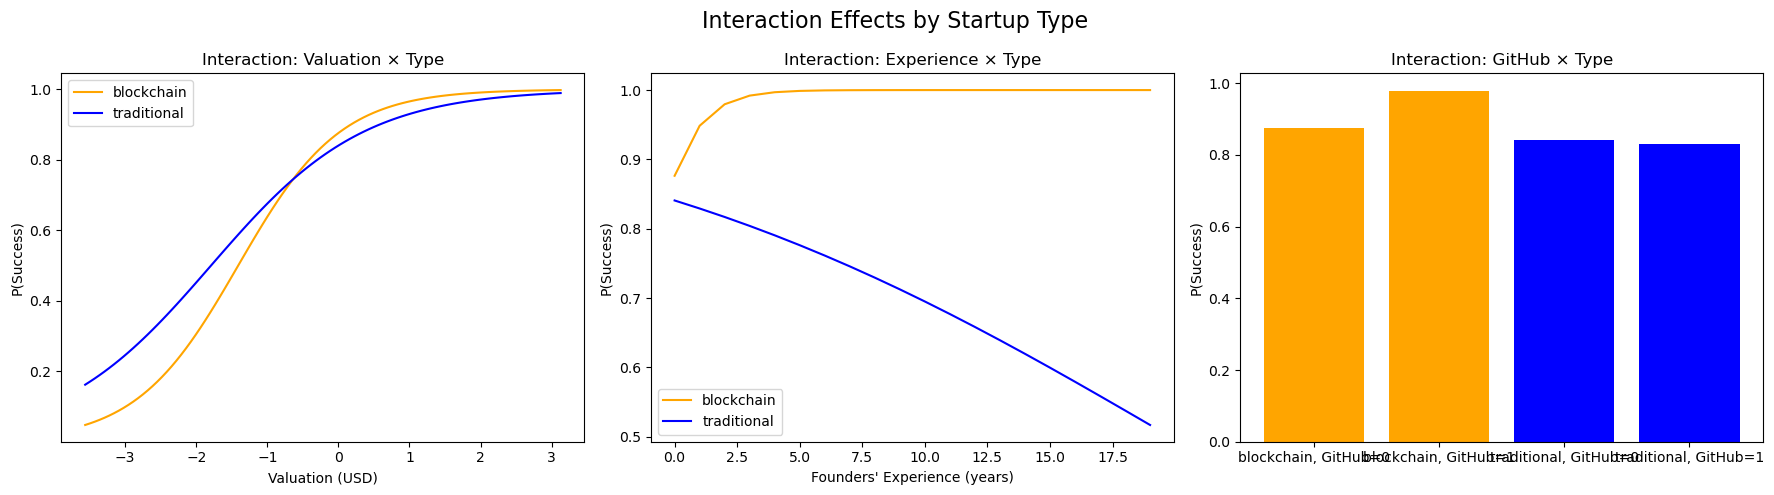

In [27]:
# Prepare data for plotting interaction effects

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
colors = {'blockchain': 'orange', 'traditional': 'blue'}

# 1. Valuation x Type
val_range = np.linspace(df_interact['Valuation_USD'].min(), df_interact['Valuation_USD'].max(), 100)
for typ in ['blockchain', 'traditional']:
    typ_bin = 1 if typ == 'blockchain' else 0
    logits = (
        logit_model.params['Intercept'] +
        logit_model.params['Valuation_USD'] * val_range +
        logit_model.params['Type_bin'] * typ_bin +
        logit_model.params['Type_bin:Valuation_USD'] * typ_bin * val_range
    )
    probs = 1 / (1 + np.exp(-logits))
    axs[0].plot(val_range, probs, label=typ, color=colors[typ])
axs[0].set_title("Interaction: Valuation × Type")
axs[0].set_xlabel("Valuation (USD)")
axs[0].set_ylabel("P(Success)")
axs[0].legend()

# 2. Experience x Type
exp_range = np.arange(0, 20)
for typ in ['blockchain', 'traditional']:
    typ_bin = 1 if typ == 'blockchain' else 0
    logits = (
        logit_model.params['Intercept'] +
        logit_model.params['Founders_Experience'] * exp_range +
        logit_model.params['Type_bin'] * typ_bin +
        logit_model.params['Type_bin:Founders_Experience'] * typ_bin * exp_range
    )
    probs = 1 / (1 + np.exp(-logits))
    axs[1].plot(exp_range, probs, label=typ, color=colors[typ])
axs[1].set_title("Interaction: Experience × Type")
axs[1].set_xlabel("Founders' Experience (years)")
axs[1].set_ylabel("P(Success)")
axs[1].legend()

# 3. Has_GitHub x Type
for typ in ['blockchain', 'traditional']:
    typ_bin = 1 if typ == 'blockchain' else 0
    for github in [0, 1]:
        label = f"{typ}, GitHub={github}"
        logits = (
            logit_model.params['Intercept'] +
            logit_model.params['Has_GitHub'] * github +
            logit_model.params['Type_bin'] * typ_bin +
            logit_model.params['Type_bin:Has_GitHub'] * typ_bin * github
        )
        prob = 1 / (1 + np.exp(-logits))
        axs[2].bar(label, prob, color=colors[typ])
axs[2].set_title("Interaction: GitHub × Type")
axs[2].set_ylabel("P(Success)")

plt.suptitle("Interaction Effects by Startup Type", fontsize=16)
plt.tight_layout()
plt.show()

### Interaction Effects by Startup Type

The plots below illustrate how the effect of key predictors on the probability of startup success varies depending on the **type of company** (blockchain vs. traditional).

#### 1. **Valuation × Type**

The first plot demonstrates a clear **positive effect of valuation** on success for both blockchain and traditional startups. However, the **slope is steeper for traditional firms** (blue line), suggesting that valuation has a stronger marginal impact on the success probability of traditional companies. In contrast, blockchain startups (orange line) reach a high probability of success even at lower valuation levels, possibly due to speculative capital inflows typical of ICO-driven fundraising.

#### 2. **Founders’ Experience × Type**

The second plot shows a **divergent pattern**:  
- For **blockchain startups**, increased founder experience correlates with **very high and quickly plateauing** success probabilities, reaching near certainty even at low levels of experience.  
- For **traditional startups**, the trend is reversed—**greater experience is associated with a decreasing probability of success**, possibly reflecting overfitting to outdated market models or risk aversion among seasoned founders.

This highlights the **nonlinear and context-dependent role** of entrepreneurial experience across startup types.

#### 3. **GitHub Presence × Type**

The third plot compares the **average predicted probability of success** across four groups based on GitHub presence and company type.  
- Blockchain startups with a public GitHub repository (`GitHub = 1`) show the **highest success probabilities**, reinforcing the importance of transparency and open-source engagement in blockchain ecosystems.  
- Traditional startups, by contrast, show only modest differences in predicted success whether or not they have a GitHub presence.

This suggests that **technical openness** (as proxied by GitHub) is a **highly valued signal in blockchain projects**, but plays a lesser role in traditional tech ventures.

---

Together, these interaction plots confirm that **predictor effects are conditional on company type**, supporting the inclusion of interaction terms in the regression model and validating the second research hypothesis (H2).


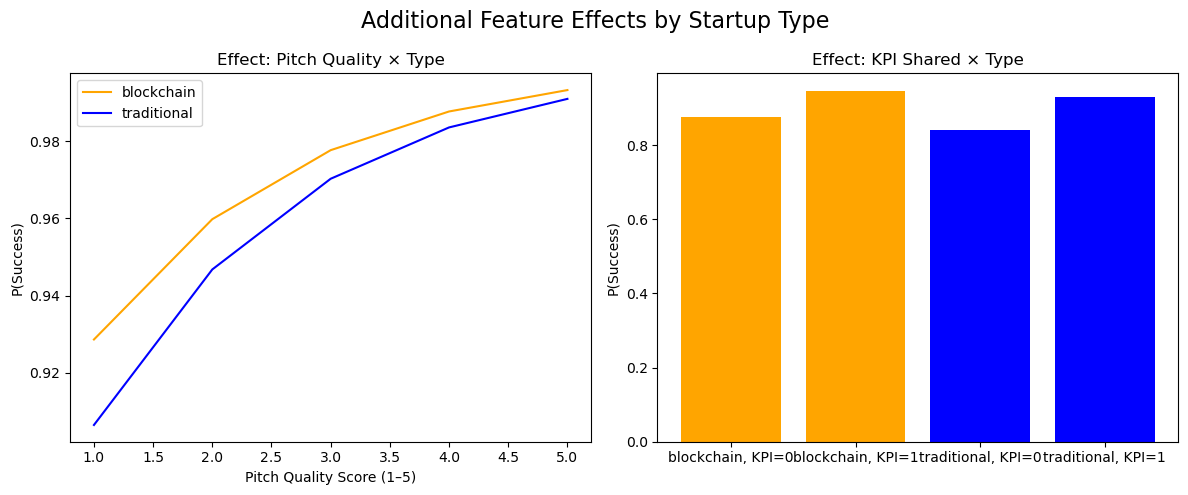

In [28]:
# Plot additional interaction-like effects for Pitch Quality Score and KPI_Shared

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# 1. Pitch Quality Score × Type
pitch_range = np.arange(1, 6)
for typ in ['blockchain', 'traditional']:
    typ_bin = 1 if typ == 'blockchain' else 0
    logits = (
        logit_model.params['Intercept'] +
        logit_model.params['Pitch_Quality_Score'] * pitch_range +
        logit_model.params['Type_bin'] * typ_bin
    )
    probs = 1 / (1 + np.exp(-logits))
    axs[0].plot(pitch_range, probs, label=typ, color=colors[typ])
axs[0].set_title("Effect: Pitch Quality × Type")
axs[0].set_xlabel("Pitch Quality Score (1–5)")
axs[0].set_ylabel("P(Success)")
axs[0].legend()

# 2. KPI_Shared × Type
for typ in ['blockchain', 'traditional']:
    typ_bin = 1 if typ == 'blockchain' else 0
    for kpi in [0, 1]:
        label = f"{typ}, KPI={kpi}"
        logits = (
            logit_model.params['Intercept'] +
            logit_model.params['KPI_Shared'] * kpi +
            logit_model.params['Type_bin'] * typ_bin
        )
        prob = 1 / (1 + np.exp(-logits))
        axs[1].bar(label, prob, color=colors[typ])
axs[1].set_title("Effect: KPI Shared × Type")
axs[1].set_ylabel("P(Success)")

plt.suptitle("Additional Feature Effects by Startup Type", fontsize=16)
plt.tight_layout()
plt.show()


### Additional Feature Effects by Startup Type

The figure above explores two additional predictors—**Pitch Quality Score** and **KPI Sharing**—and how their effects on success probability vary by startup type.

#### 1. **Pitch Quality Score × Type**

The left plot shows that **higher pitch quality scores** are associated with **increased probability of success** for both blockchain and traditional startups.  
- The relationship is **monotonic** and relatively linear across the scale from 1 to 5.  
- While both groups benefit from improved pitch quality, the **effect is consistently stronger for blockchain startups**, which likely rely more heavily on digital presentations and investor-facing narratives during fundraising (e.g., during ICO campaigns).

This suggests that in blockchain environments—where face-to-face interaction is limited and trust is often mediated through documentation and design—the **perceived professionalism of the pitch** plays a slightly more prominent role in project validation.

#### 2. **KPI_Shared × Type**

The right-hand plot displays the predicted probability of success across combinations of **KPI transparency** (`KPI_Shared`) and **startu**_


### Violin plots

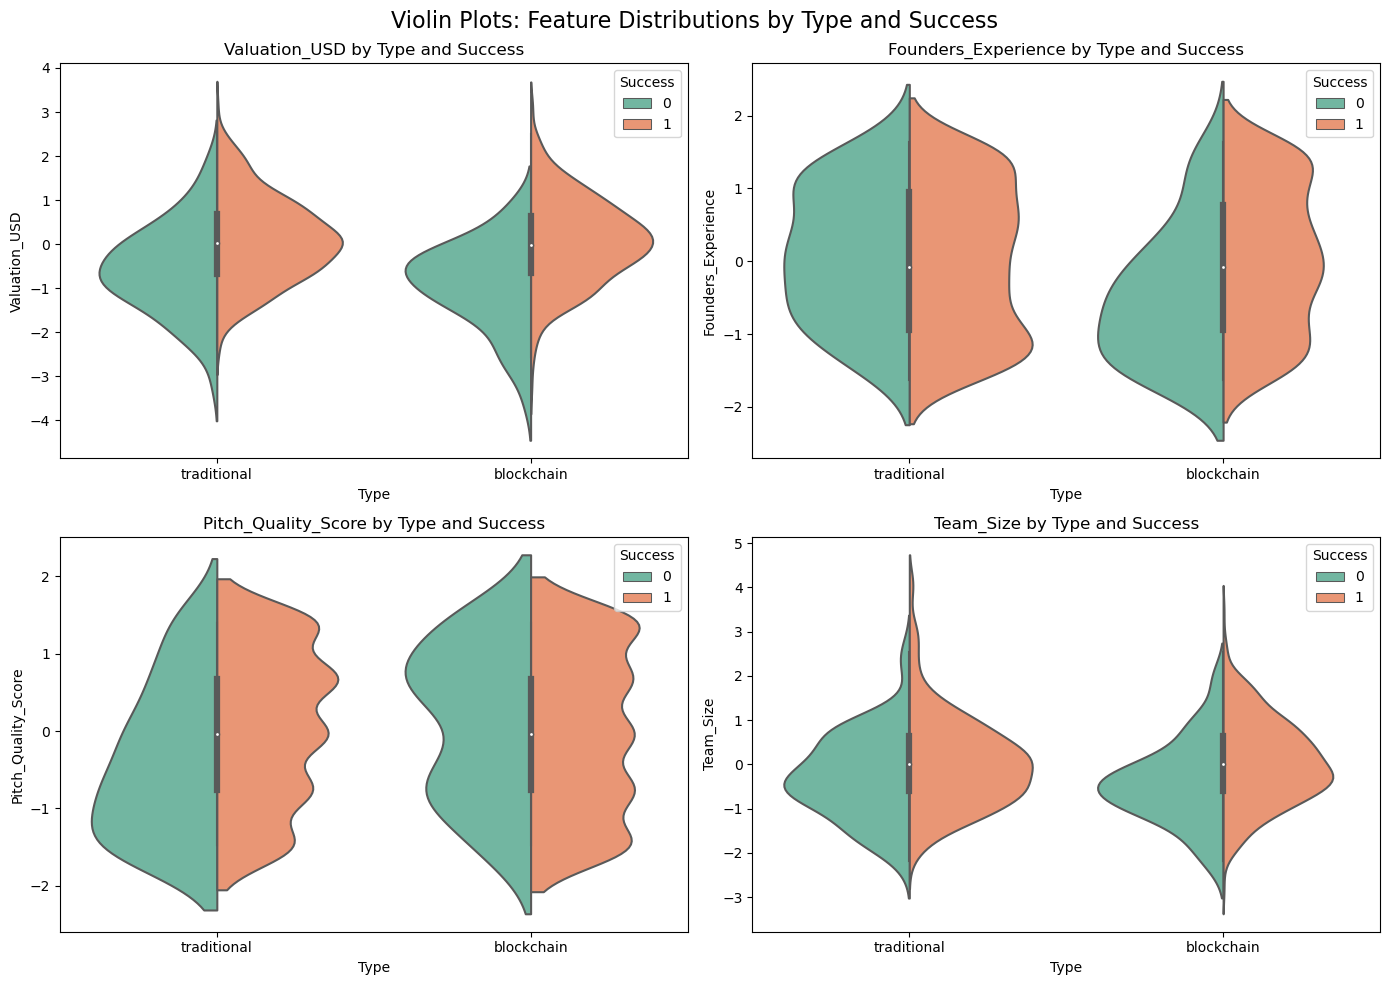

In [29]:
features_to_plot = ['Valuation_USD', 'Founders_Experience', 'Pitch_Quality_Score', 'Team_Size']
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()

for i, feature in enumerate(features_to_plot):
    sns.violinplot(
        data=df_interact,
        x='Type',
        y=feature,
        hue='Success',
        split=True,
        ax=axs[i],
        palette='Set2'
    )
    axs[i].set_title(f"{feature} by Type and Success")
    axs[i].legend(title='Success', loc='upper right')

plt.suptitle("Violin Plots: Feature Distributions by Type and Success", fontsize=16)
plt.tight_layout()
plt.show()

### Violin Plots: Feature Distributions by Type and Success

The violin plots illustrate the distributions of selected continuous predictors across **startup type** (blockchain vs. traditional) and **success status** (0 = unsuccessful, 1 = successful). These plots offer insights into whether the central tendencies and variances of key features differ by outcome within each group.

#### 1. **Valuation_USD**
- For both traditional and blockchain startups, successful companies tend to have **higher valuations**.
- The density is shifted rightward (positive side) for successful startups, with blockchain startups showing slightly more **right-skewed success tails**, suggesting a few highly valued successes.

#### 2. **Founders_Experience**
- Among traditional startups, the distribution of founder experience is more concentrated for successful companies but **not dramatically different** from unsuccessful ones.
- In blockchain startups, successful companies also show a **mildly right-shifted distribution**, suggesting that experience may help but is not decisive.

#### 3. **Pitch_Quality_Score**
- A noticeable rightward shift is observed in the distribution of **successful startups** in both groups.
- The effect is slightly more pronounced in blockchain startups, aligning with earlier regression and interaction results indicating that **pitch quality is more critical in blockchain contexts**.

#### 4. **Team_Size**
- In both groups, **larger teams are more common among successful startups**, with the effect being **more pronounced for blockchain firms**.
- The density distribution among blockchain successes shows a clear peak in the upper range of team size, while traditional startups are more evenly distributed.

---

**Conclusion:**  
These plots visually reinforce several findings from the logistic regression and interaction models:  
- **Valuation and team size** are strongly associated with success, especially in blockchain firms.  
- **Pitch quality** appears to be a meaningful discriminator across both groups.  
- **Founders' experience**, though included in models, may have **weaker distributional separation**, especially in traditional startups.

Such distributional insights can inform further robustness checks, e.g., via stratified models or non-parametric tests.


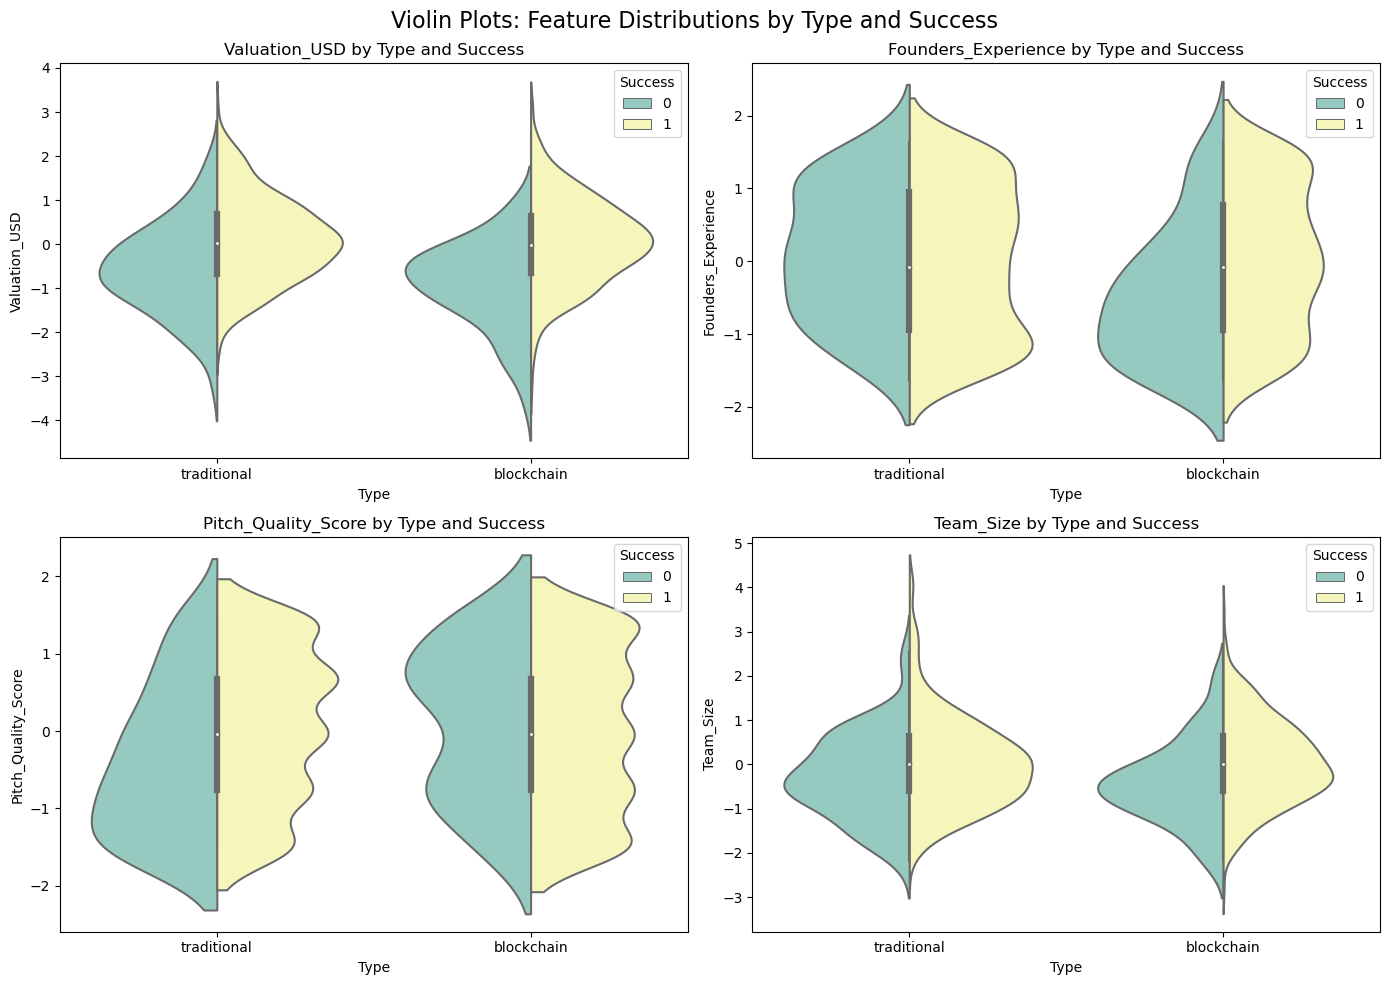

In [30]:
features_to_plot = ['Valuation_USD', 'Founders_Experience', 'Pitch_Quality_Score', 'Team_Size']

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()

for i, feature in enumerate(features_to_plot):
    sns.violinplot(
        data=df_interact,
        x='Type',
        y=feature,
        hue='Success',
        split=True,
        ax=axs[i],
        palette='Set3'
    )
    axs[i].set_title(f"{feature} by Type and Success")
    axs[i].legend(title='Success', loc='upper right')

plt.suptitle("Violin Plots: Feature Distributions by Type and Success", fontsize=16)
plt.tight_layout()
plt.show()

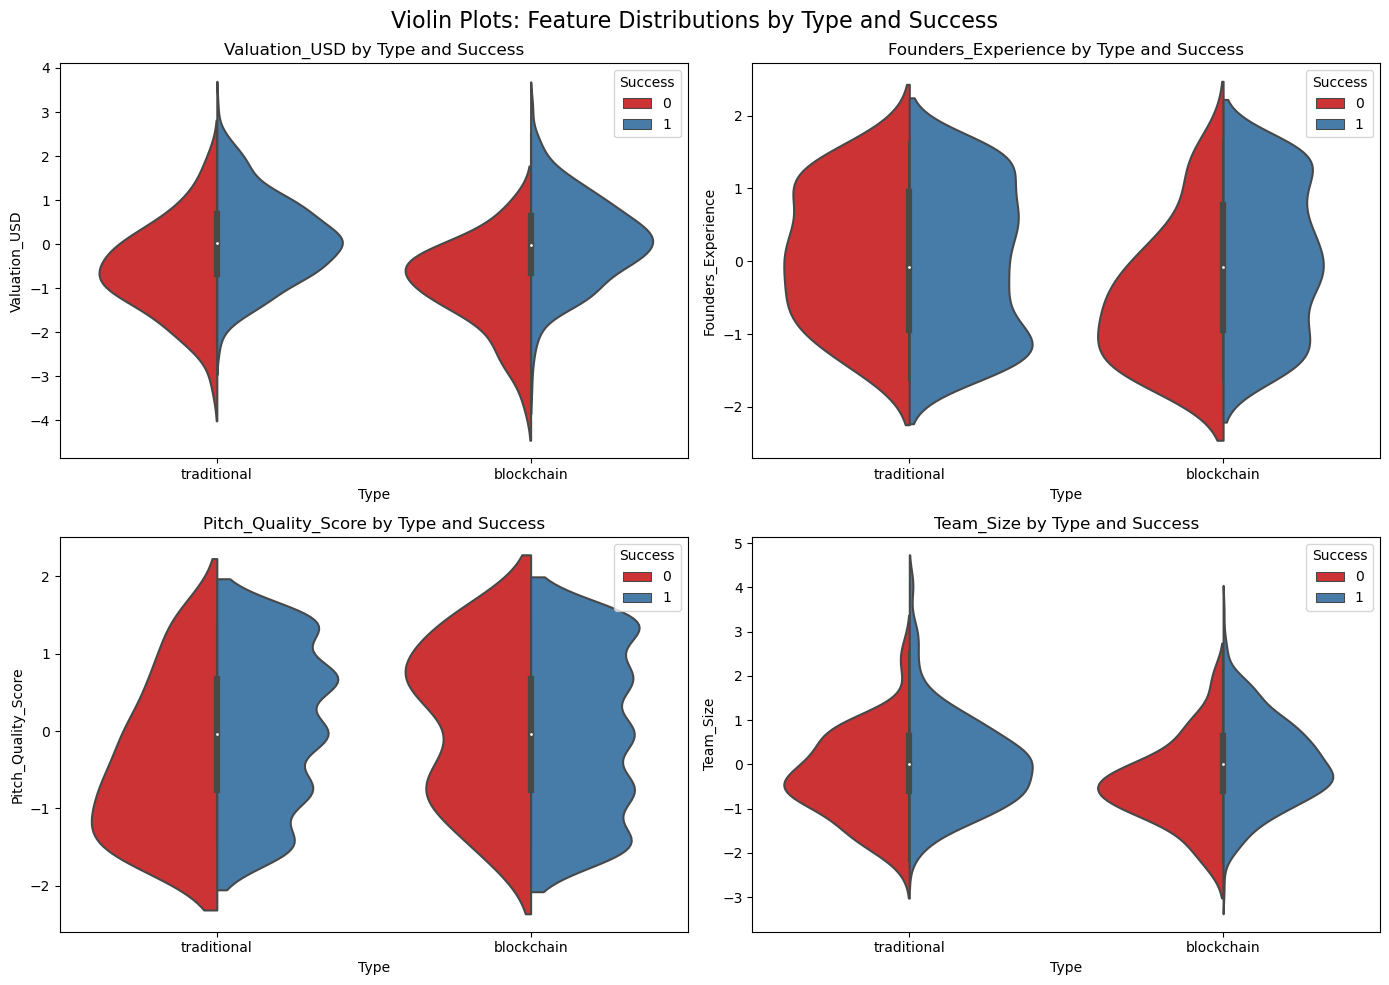

In [31]:
features_to_plot = ['Valuation_USD', 'Founders_Experience', 'Pitch_Quality_Score', 'Team_Size']

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()

for i, feature in enumerate(features_to_plot):
    sns.violinplot(
        data=df_interact,
        x='Type',
        y=feature,
        hue='Success',
        split=True,
        ax=axs[i],
        palette='Set1'
    )
    axs[i].set_title(f"{feature} by Type and Success")
    axs[i].legend(title='Success', loc='upper right')

plt.suptitle("Violin Plots: Feature Distributions by Type and Success", fontsize=16)
plt.tight_layout()
plt.show()

In [32]:
df_interact

,Type,Success,Valuation_USD,Team_Size,Has_Twitter,Has_GitHub,Tone_Index,Uncertainty_Index,Founders_Experience,Business_Model_Clarity,Pitch_Quality_Score,KPI_Shared,Type_bin
0,traditional,1,-0.785462,0.962427,0,0,1.111179,-0.798860,1.637099,0.701528,-0.756982,0,0
1,blockchain,1,1.072474,0.017327,1,1,-0.730450,-0.268969,-0.251531,-1.450398,0.675339,0,1
2,blockchain,1,1.384782,-0.297706,1,1,-1.289991,0.537462,0.435243,1.418836,0.675339,1,1
3,traditional,1,-0.538464,0.962427,0,0,1.013309,-0.501294,-1.625081,1.418836,-1.473142,1,0
4,blockchain,1,-2.245380,0.332360,1,0,-0.022181,-0.741454,-0.766612,0.701528,0.675339,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,traditional,1,0.674900,-0.927773,1,1,0.581008,-1.364368,0.606937,0.701528,1.391500,1,0
996,blockchain,1,0.834610,1.592493,1,0,0.440549,0.874752,-0.594919,-0.015781,0.675339,1,1
997,traditional,1,1.950576,-0.297706,1,1,0.208528,-0.023601,0.606937,-1.450398,0.675339,1,0
998,traditional,1,-0.922194,0.017327,1,1,-0.283642,2.010977,-1.453387,-1.450398,-0.040821,0,0


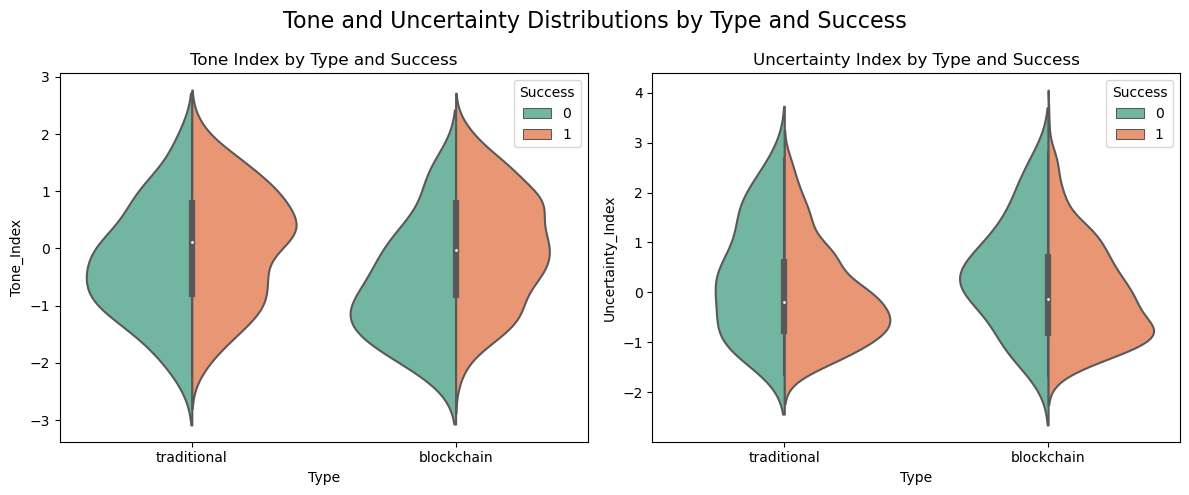

In [33]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.violinplot(
    data=df_interact,
    x='Type',
    y='Tone_Index',
    hue='Success',
    split=True,
    ax=axs[0],
    palette='Set2'
)
axs[0].set_title("Tone Index by Type and Success")
axs[0].legend(title='Success', loc='upper right')

sns.violinplot(
    data=df_interact,
    x='Type',
    y='Uncertainty_Index',
    hue='Success',
    split=True,
    ax=axs[1],
    palette='Set2'
)
axs[1].set_title("Uncertainty Index by Type and Success")
axs[1].legend(title='Success', loc='upper right')

plt.suptitle("Tone and Uncertainty Distributions by Type and Success", fontsize=16)
plt.tight_layout()
plt.show()


### Tone and Uncertainty Distributions by Startup Type and Success

The plots below display the standardized distributions of two NLP-derived textual features—**Tone Index** and **Uncertainty Index**—segmented by **startup type** (traditional vs. blockchain) and **success status** (0 = unsuccessful, 1 = successful).

#### 1. **Tone Index**
- In both traditional and blockchain startups, the distribution of **successful projects** is clearly **shifted toward higher Tone Index values** (i.e., more positive or confident language).
- The separation between successful and unsuccessful cases is more noticeable in **blockchain startups**, supporting earlier regression results where tone was a significant predictor.
- This suggests that **positive linguistic framing** in pitch materials or whitepapers plays a valuable signaling role, particularly in digitally native fundraising environments.

#### 2. **Uncertainty Index**
- In both startup types, successful ventures tend to exhibit **lower Uncertainty Index values**, indicating **clearer and more focused language**.
- The distributions for successful cases are concentrated around lower values, while unsuccessful cases are more dispersed, with higher densities in ambiguous or vague textual zones.
- These visual patterns reinforce the finding that **linguistic precision** contributes positively to startup success and validate the **negative regression coefficient** for Uncertainty Index.

---

**Conclusion:**  
Textual features such as **tone and uncertainty** provide meaningful signals to investors and stakeholders. Clear, confident, and unambiguous communication increases the probability of startup success, especially in **blockchain ecosystems**, where trust is mediated primarily through language and code rather than institutional backing.


# Random Forest

In [34]:
df_interact.head()

,Type,Success,Valuation_USD,Team_Size,Has_Twitter,Has_GitHub,Tone_Index,Uncertainty_Index,Founders_Experience,Business_Model_Clarity,Pitch_Quality_Score,KPI_Shared,Type_bin
0,traditional,1,-0.785462,0.962427,0,0,1.111179,-0.798860,1.637099,0.701528,-0.756982,0,0
1,blockchain,1,1.072474,0.017327,1,1,-0.730450,-0.268969,-0.251531,-1.450398,0.675339,0,1
2,blockchain,1,1.384782,-0.297706,1,1,-1.289991,0.537462,0.435243,1.418836,0.675339,1,1
3,traditional,1,-0.538464,0.962427,0,0,1.013309,-0.501294,-1.625081,1.418836,-1.473142,1,0
4,blockchain,1,-2.245380,0.332360,1,0,-0.022181,-0.741454,-0.766612,0.701528,0.675339,1,1


In [35]:
# Prepare data for random forest
features = [
    'Valuation_USD', 'Team_Size', 'Has_Twitter', 'Has_GitHub',
    'Tone_Index', 'Uncertainty_Index', 'Founders_Experience',
    'Business_Model_Clarity', 'Pitch_Quality_Score', 'KPI_Shared'
]
X = df_interact[features]
y = df_interact['Success']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate model
y_pred = rf_model.predict(X_test)
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

In [36]:
report_df

,precision,recall,f1-score,support
0,0.833333,0.151515,0.256410,33.000000
1,0.904762,0.996255,0.948307,267.000000
accuracy,0.903333,0.903333,0.903333,0.903333
macro avg,0.869048,0.573885,0.602358,300.000000
weighted avg,0.896905,0.903333,0.872198,300.000000


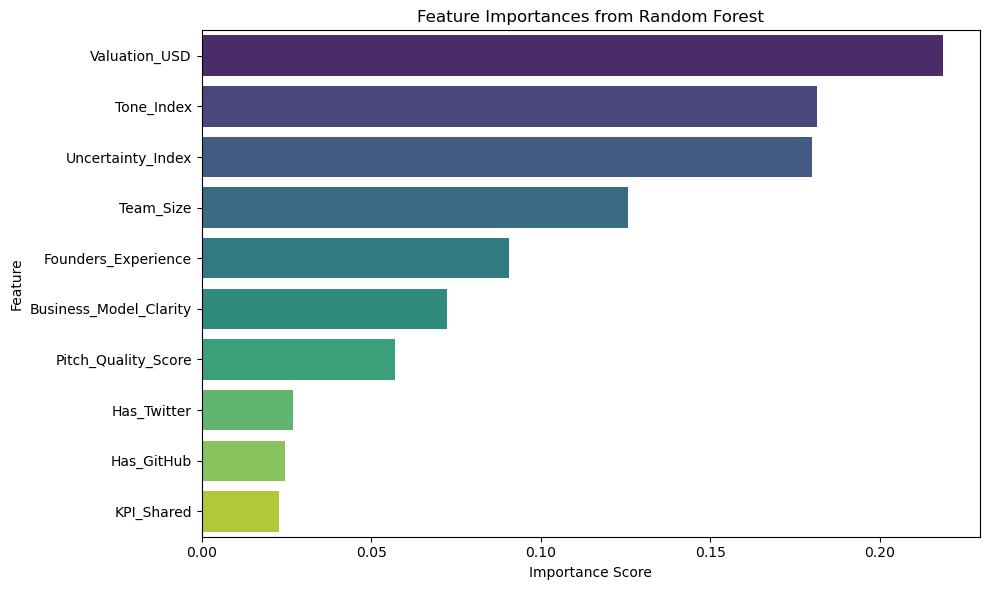

In [37]:
# Extract and display feature importances from the trained Random Forest model

importances = rf_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title("Feature Importances from Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


### Feature Importances from Random Forest Model

The bar plot above shows the **relative importance of predictors** in determining startup success, as computed by a **Random Forest classifier**. Feature importance reflects the **mean decrease in impurity (MDI)**—i.e., how much each variable contributes to improving the model’s predictive performance.

#### 🔝 Top Predictors:
1. **Valuation_USD** — By far the most important variable, suggesting that a startup's market valuation is the strongest standalone indicator of success.
2. **Tone_Index** — The second most influential predictor, highlighting the role of **positive and confident language** in determining outcomes.
3. **Uncertainty_Index** — Negatively associated with success in regression models and ranked highly here, suggesting that **linguistic clarity** is a key non-financial success factor.

#### ⚙️ Mid-tier Predictors:
4. **Team_Size** — Strong contributor, consistent with previous regression results showing that larger teams correlate with success.
5. **Founders_Experience** — Moderately important, indicating that entrepreneurial background plays a role, though weaker than valuation or textual tone.
6. **Business_Model_Clarity** — A meaningful factor, reinforcing the hypothesis that well-defined business models contribute to legitimacy and traction.

#### 📉 Lower-Tier Predictors:
- **Pitch_Quality_Score**, **Has_Twitter**, **Has_GitHub**, and **KPI_Shared** show **lower importance scores**, suggesting that while they may add marginal explanatory value, they are not critical drivers of success in the ensemble model.

---

**Conclusion:**  
The Random Forest model supports the regression-based findings by identifying **valuation, tone, and clarity** as the most impactful features, combining financial strength with communication effectiveness. The importance of **text-based indicators** underscores the need to integrate **NLP-derived metrics** into predictive modeling for startup evaluation.


## Partial Dependence

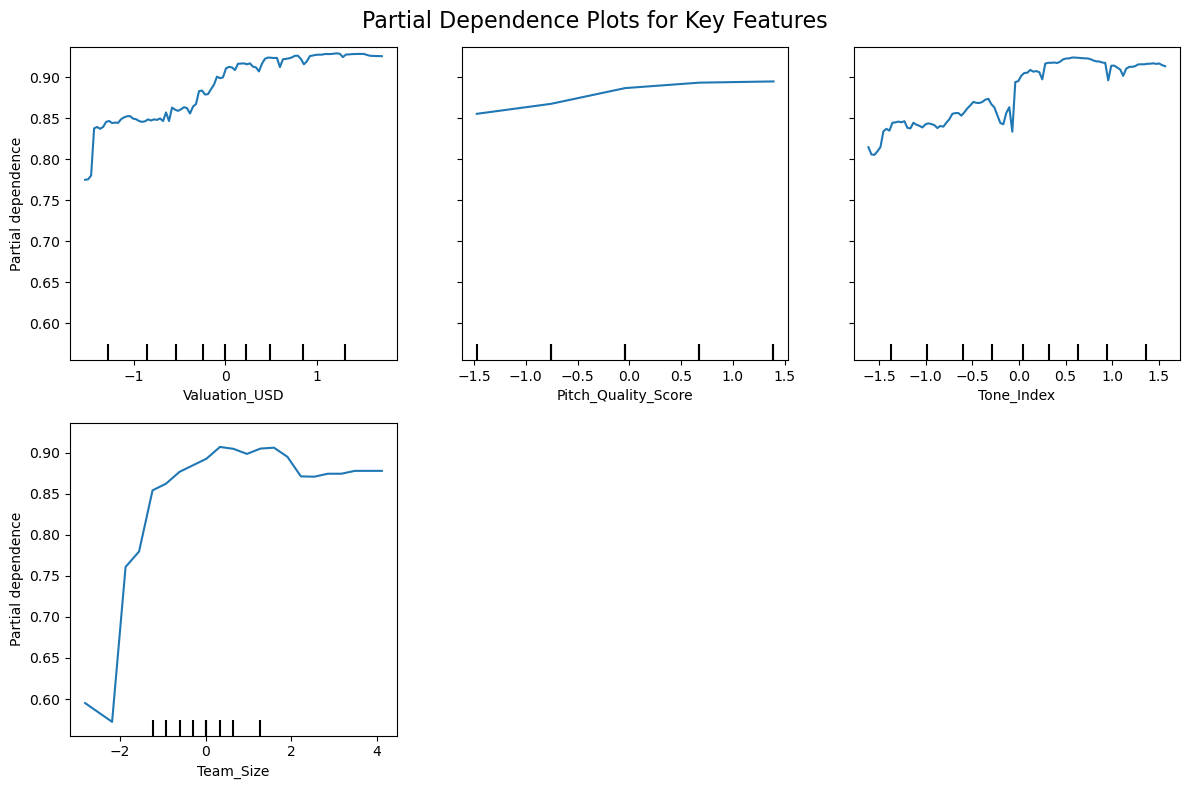

In [38]:
# Plot partial dependence plots for top 4 features
top_features = ['Valuation_USD', 'Pitch_Quality_Score', 'Tone_Index', 'Team_Size']

fig, ax = plt.subplots(figsize=(12, 8))
PartialDependenceDisplay.from_estimator(
    rf_model,
    X,
    features=top_features,
    kind='average',
    ax=ax
)
plt.suptitle("Partial Dependence Plots for Key Features", fontsize=16)
plt.tight_layout()
plt.show()

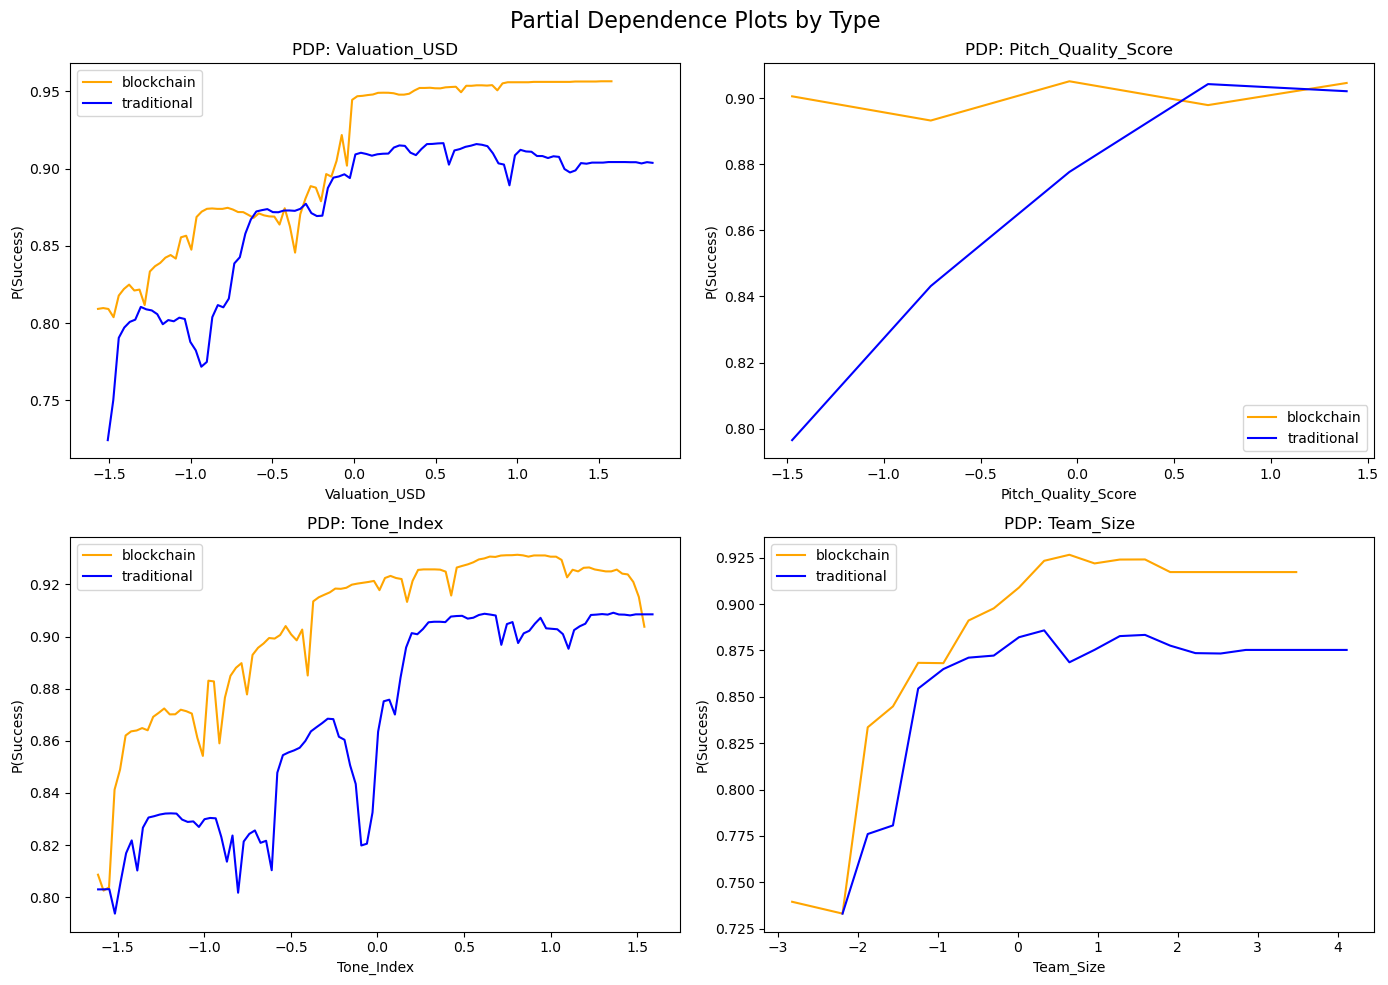

In [39]:
# Updated PDP comparison for blockchain vs traditional
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()

for i, feature in enumerate(top_features):
    for typ, color in zip(['blockchain', 'traditional'], ['orange', 'blue']):
        subset = df_interact[df_interact['Type'] == typ]
        X_sub = subset[features]
        y_sub = subset['Success']
        model_sub = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_sub, y_sub)

        pd_result = partial_dependence(model_sub, X_sub, [feature])
        values = pd_result['values'][0]
        avg_preds = pd_result['average'][0]

        axs[i].plot(values, avg_preds, label=typ, color=color)
        axs[i].set_title(f"PDP: {feature}")
        axs[i].set_xlabel(feature)
        axs[i].set_ylabel("P(Success)")
        axs[i].legend()

plt.suptitle("Partial Dependence Plots by Type", fontsize=16)
plt.tight_layout()
plt.show()

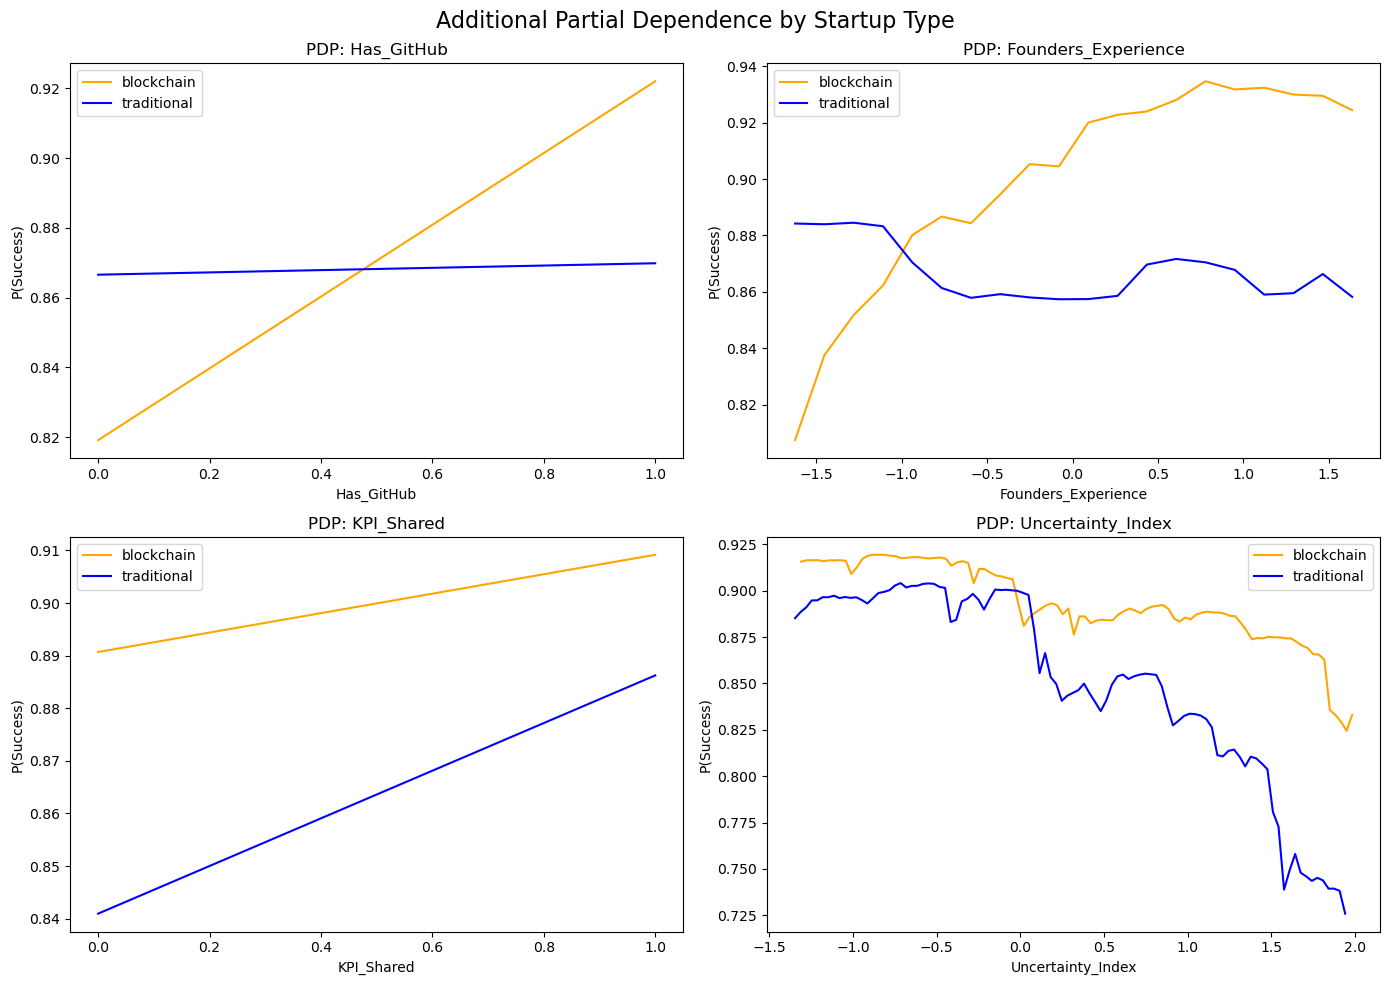

In [40]:
# Define additional features for PDP
additional_features = ['Has_GitHub', 'Founders_Experience', 'KPI_Shared', 'Uncertainty_Index']

# Plot PDPs for these features split by Type
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()

for i, feature in enumerate(additional_features):
    for typ, color in zip(['blockchain', 'traditional'], ['orange', 'blue']):
        subset = df_interact[df_interact['Type'] == typ]
        X_sub = subset[features]
        y_sub = subset['Success']
        model_sub = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_sub, y_sub)

        pd_result = partial_dependence(model_sub, X_sub, [feature])
        values = pd_result['values'][0]
        avg_preds = pd_result['average'][0]

        axs[i].plot(values, avg_preds, label=typ, color=color)
        axs[i].set_title(f"PDP: {feature}")
        axs[i].set_xlabel(feature)
        axs[i].set_ylabel("P(Success)")
        axs[i].legend()

plt.suptitle("Additional Partial Dependence by Startup Type", fontsize=16)
plt.tight_layout()
plt.show()

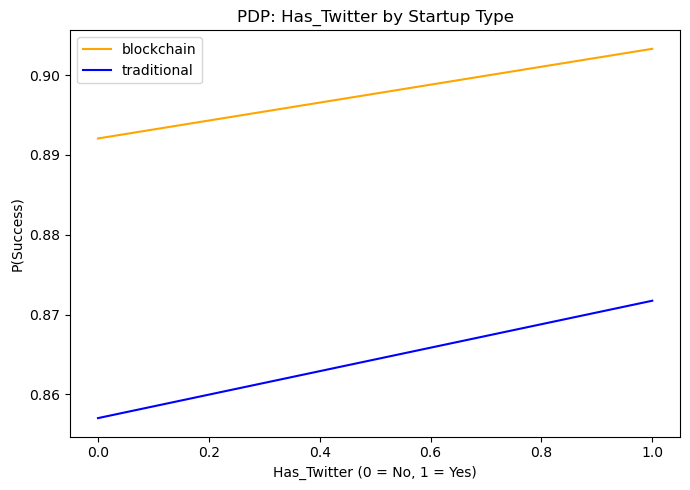

In [41]:
# Plot PDP for Has_Twitter split by Type
fig, ax = plt.subplots(figsize=(7, 5))

for typ, color in zip(['blockchain', 'traditional'], ['orange', 'blue']):
    subset = df_interact[df_interact['Type'] == typ]
    X_sub = subset[features]
    y_sub = subset['Success']
    model_sub = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_sub, y_sub)

    pd_result = partial_dependence(model_sub, X_sub, ['Has_Twitter'])
    values = pd_result['values'][0]
    avg_preds = pd_result['average'][0]

    ax.plot(values, avg_preds, label=typ, color=color)

ax.set_title("PDP: Has_Twitter by Startup Type")
ax.set_xlabel("Has_Twitter (0 = No, 1 = Yes)")
ax.set_ylabel("P(Success)")
ax.legend()
plt.tight_layout()
plt.show()


#  Decision trees

In [42]:
X_train.head()

,Valuation_USD,Team_Size,Has_Twitter,Has_GitHub,Tone_Index,Uncertainty_Index,Founders_Experience,Business_Model_Clarity,Pitch_Quality_Score,KPI_Shared
541,0.712650,-0.612740,1,1,-2.056258,2.358036,1.122018,-0.733089,-0.040821,1
440,1.203143,-0.297706,1,1,-0.343095,0.632723,1.122018,-0.733089,-0.040821,0
482,-1.304913,0.017327,1,1,1.629891,1.771739,-1.281693,-0.733089,0.675339,1
422,-0.905926,0.017327,0,0,-0.204273,-0.933899,0.778631,1.418836,-1.473142,0
778,0.132295,-1.242806,1,1,-0.418282,-0.737650,0.435243,1.418836,-0.040821,1


In [43]:
y_train.head()

541    0
440    1
482    1
422    0
778    1
Name: Success, dtype: int64

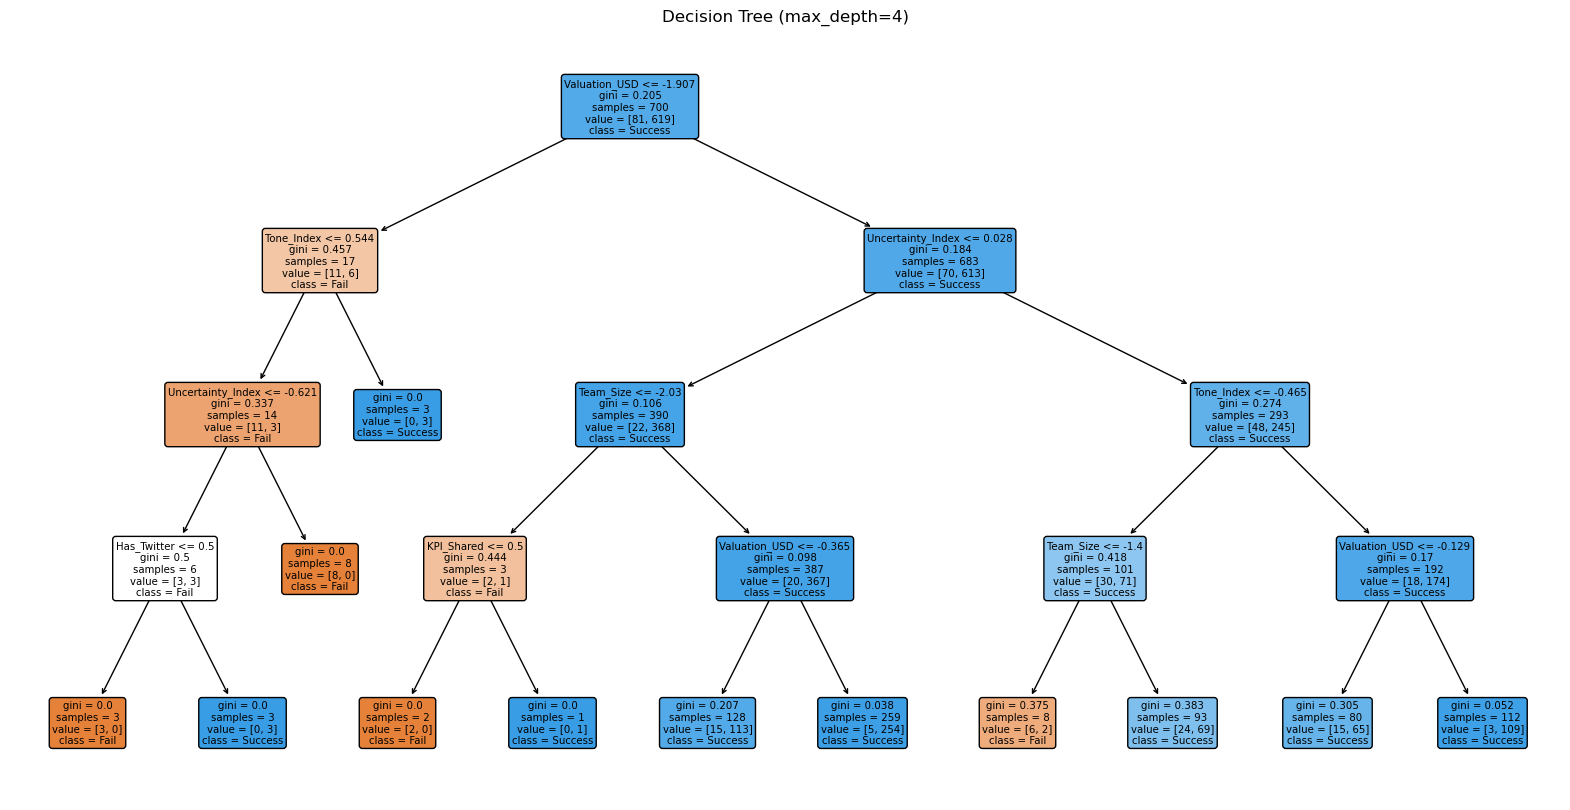

In [44]:
# Fit a simple decision tree
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)

# Plot the tree
plt.figure(figsize=(20, 10))
plot_tree(
    tree_model,
    feature_names=features,
    class_names=['Fail', 'Success'],
    filled=True,
    rounded=True
)
plt.title("Decision Tree (max_depth=4)")
plt.show()

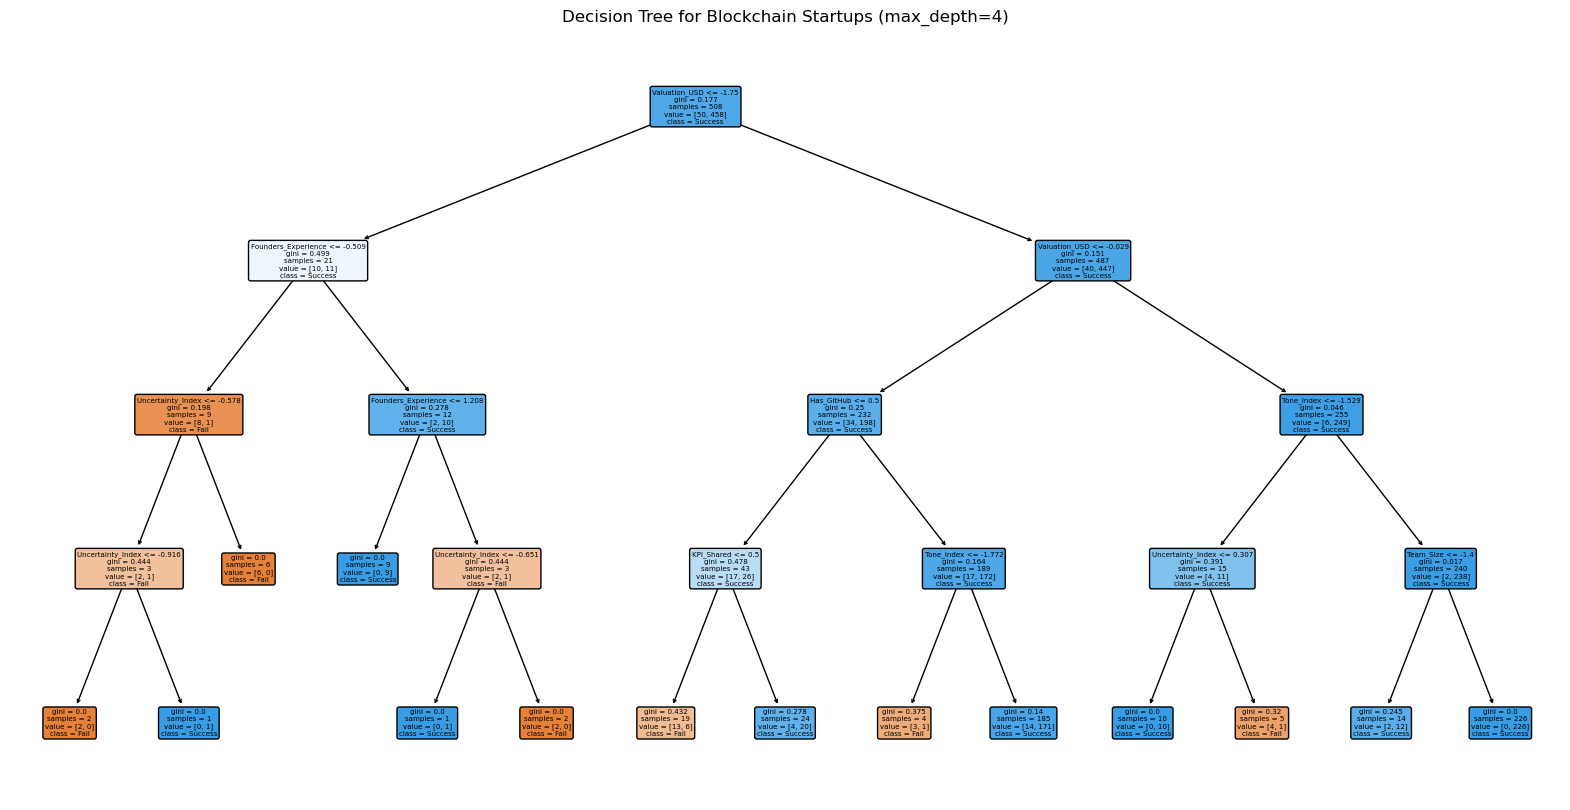

In [45]:
# Filter data for blockchain only
blockchain_data = df_interact[df_interact['Type'] == 'blockchain']
X_block = blockchain_data[features]
y_block = blockchain_data['Success']

# Train a decision tree for blockchain startups
tree_block = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_block.fit(X_block, y_block)

# Plot the blockchain-specific decision tree
plt.figure(figsize=(20, 10))
plot_tree(
    tree_block,
    feature_names=features,
    class_names=['Fail', 'Success'],
    filled=True,
    rounded=True
)
plt.title("Decision Tree for Blockchain Startups (max_depth=4)")
plt.show()

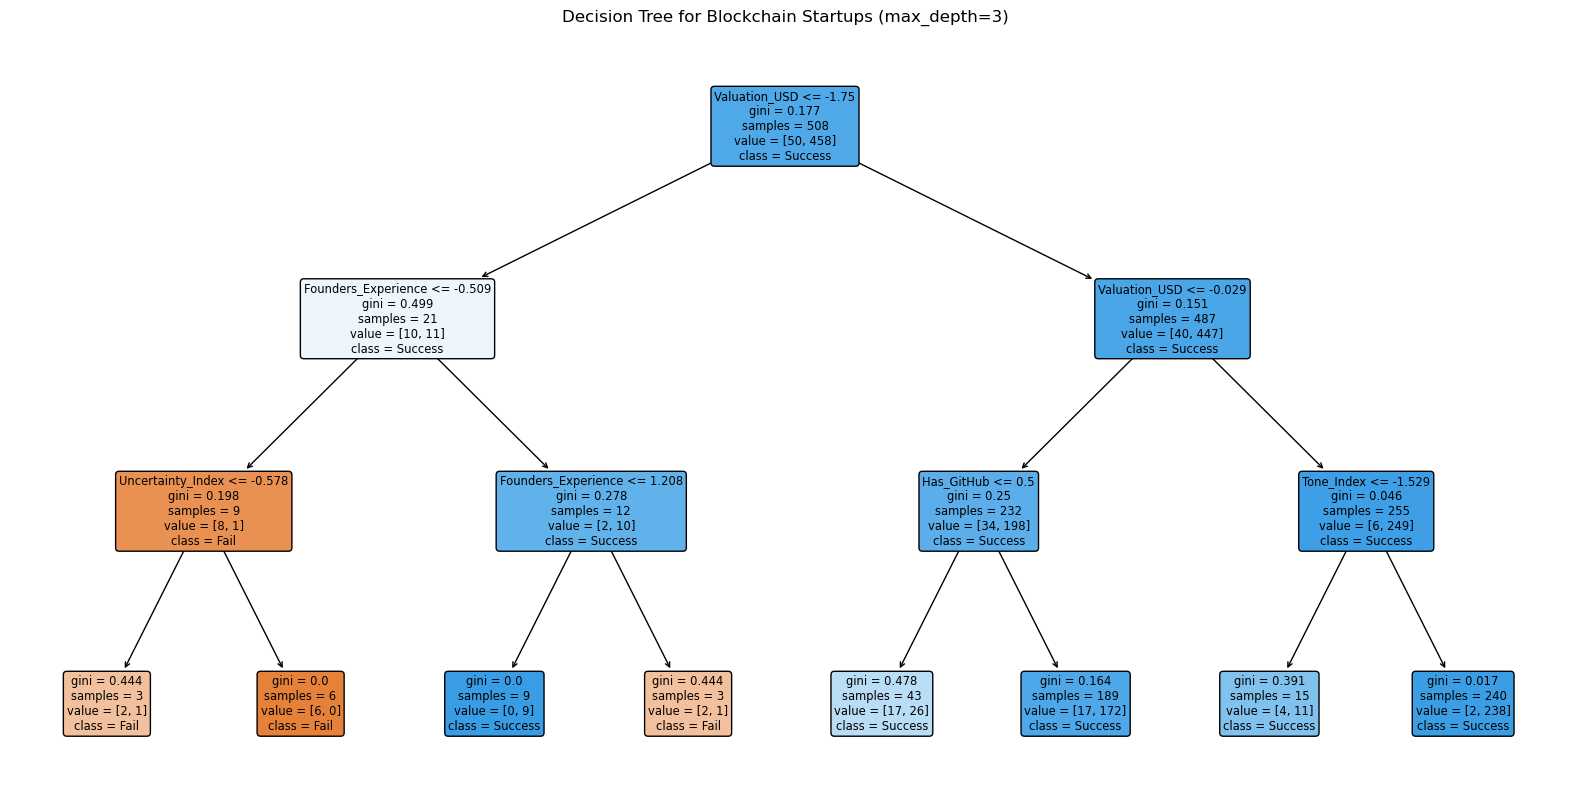

In [46]:
# Filter data for blockchain only
blockchain_data = df_interact[df_interact['Type'] == 'blockchain']
X_block = blockchain_data[features]
y_block = blockchain_data['Success']

# Train a decision tree for blockchain startups
tree_block = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_block.fit(X_block, y_block)

# Plot the blockchain-specific decision tree
plt.figure(figsize=(20, 10))
plot_tree(
    tree_block,
    feature_names=features,
    class_names=['Fail', 'Success'],
    filled=True,
    rounded=True
)
plt.title("Decision Tree for Blockchain Startups (max_depth=3)")
plt.show()

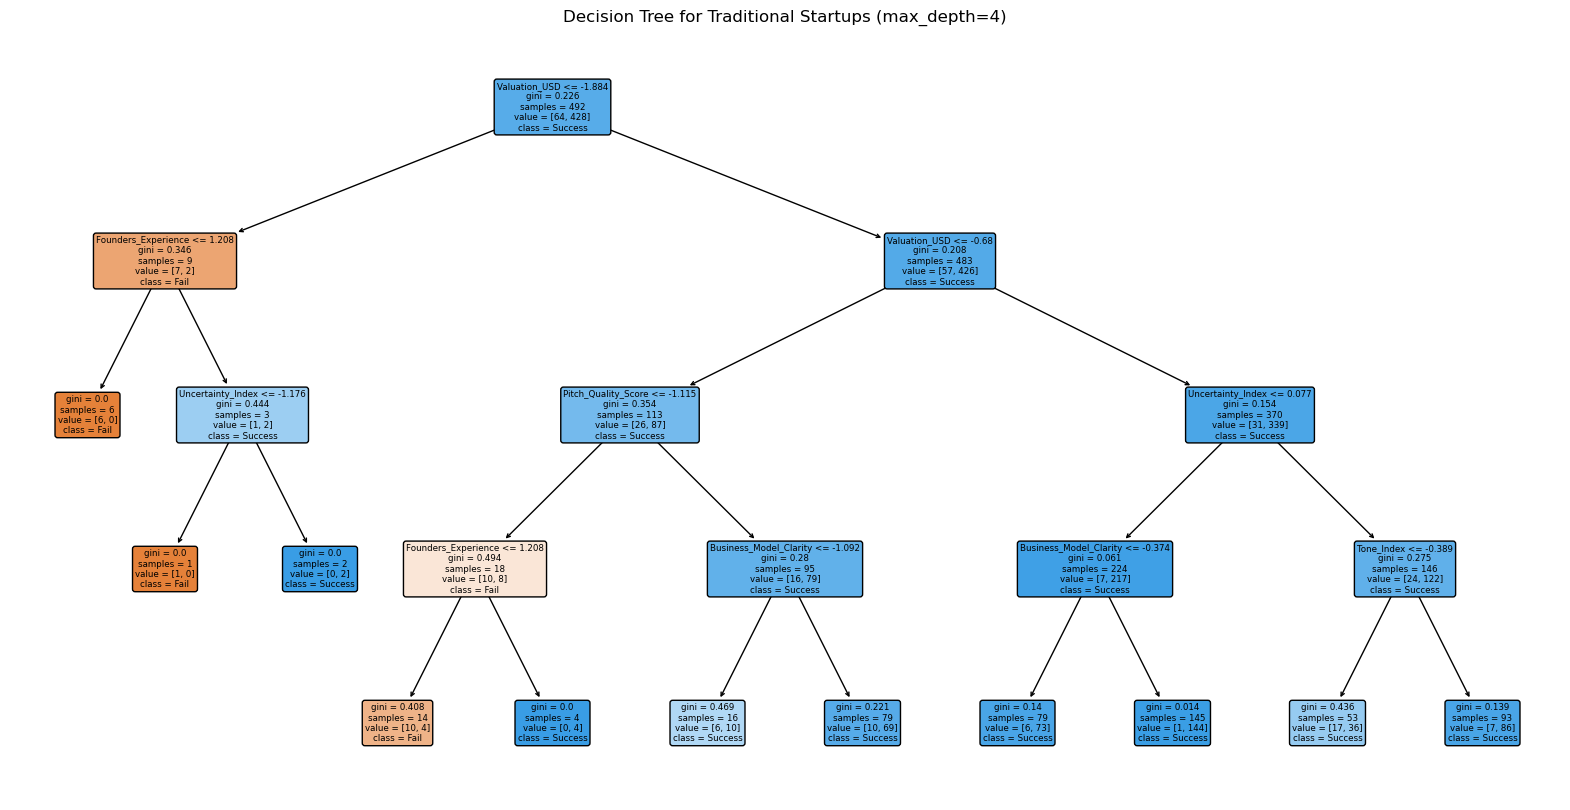

In [47]:
# Filter data for traditional startups only
traditional_data = df_interact[df_interact['Type'] == 'traditional']
X_trad = traditional_data[features]
y_trad = traditional_data['Success']

# Train a decision tree for traditional startups
tree_trad = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_trad.fit(X_trad, y_trad)

# Plot the traditional-specific decision tree
plt.figure(figsize=(20, 10))
plot_tree(
    tree_trad,
    feature_names=features,
    class_names=['Fail', 'Success'],
    filled=True,
    rounded=True
)
plt.title("Decision Tree for Traditional Startups (max_depth=4)")
plt.show()

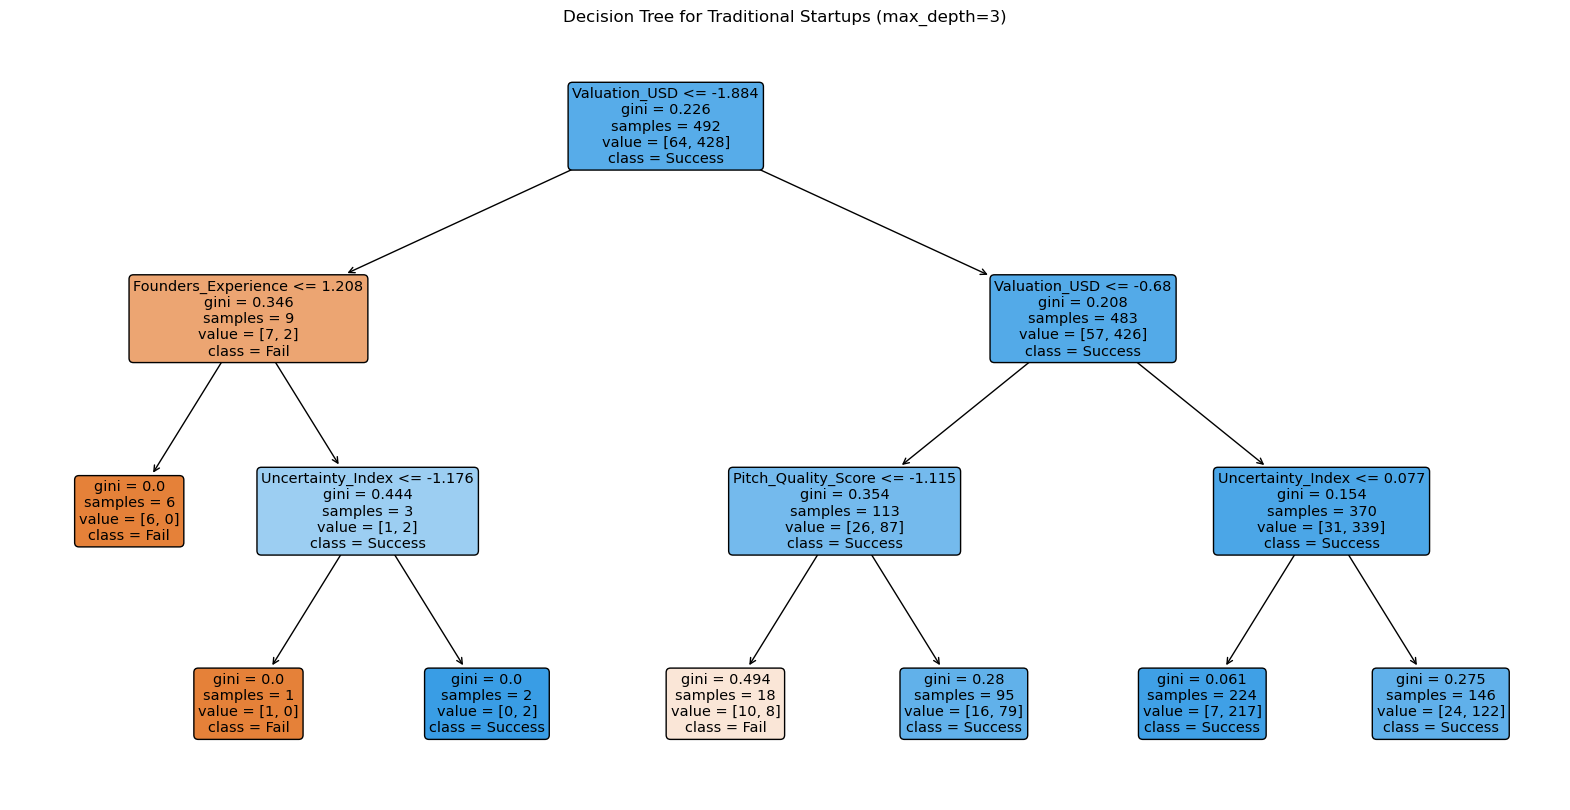

In [48]:
# Filter data for traditional startups only
traditional_data = df_interact[df_interact['Type'] == 'traditional']
X_trad = traditional_data[features]
y_trad = traditional_data['Success']

# Train a decision tree for traditional startups
tree_trad = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_trad.fit(X_trad, y_trad)

# Plot the traditional-specific decision tree
plt.figure(figsize=(20, 10))
plot_tree(
    tree_trad,
    feature_names=features,
    class_names=['Fail', 'Success'],
    filled=True,
    rounded=True
)
plt.title("Decision Tree for Traditional Startups (max_depth=3)")
plt.show()

In [49]:
import dtreeviz

In [50]:
#pip install dtreeviz

In [51]:
from dtreeviz import dtreeviz

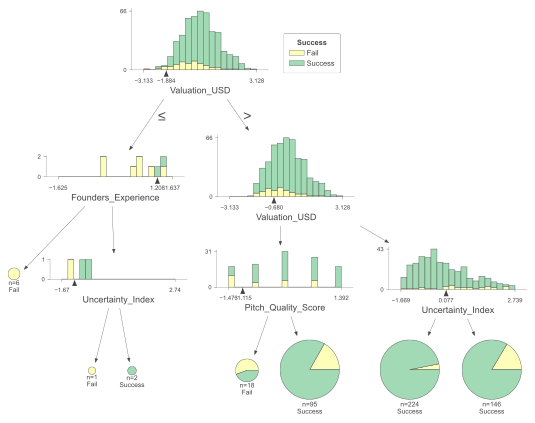

In [52]:
from dtreeviz.models.shadow_decision_tree import ShadowDecTree
from dtreeviz import model

# Prepare data
traditional_data = df_interact[df_interact['Type'] == 'traditional']
X_trad = traditional_data[features]
y_trad = traditional_data['Success']

# Fit decision tree
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_trad, y_trad)

# Create dtreeviz model object
viz_model = model(
    clf,
    X_train=X_trad,
    y_train=y_trad,
    feature_names=features,
    class_names=["Fail", "Success"],
    target_name="Success"
)

# Display the visualization
viz_model.view()


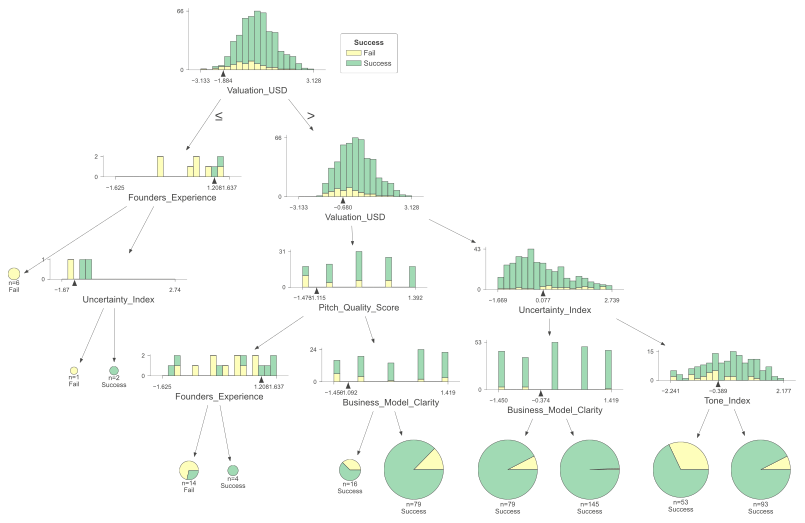

In [53]:
from dtreeviz.models.shadow_decision_tree import ShadowDecTree
from dtreeviz import model

# Prepare data
traditional_data = df_interact[df_interact['Type'] == 'traditional']
X_trad = traditional_data[features]
y_trad = traditional_data['Success']

# Fit decision tree
clf = DecisionTreeClassifier(max_depth=4, random_state=42)
clf.fit(X_trad, y_trad)

# Create dtreeviz model object
viz_model = model(
    clf,
    X_train=X_trad,
    y_train=y_trad,
    feature_names=features,
    class_names=["Fail", "Success"],
    target_name="Success"
)

# Display the visualization
viz_model.view()


In [54]:
df = df_interact.copy()

In [55]:
df.head()

,Type,Success,Valuation_USD,Team_Size,Has_Twitter,Has_GitHub,Tone_Index,Uncertainty_Index,Founders_Experience,Business_Model_Clarity,Pitch_Quality_Score,KPI_Shared,Type_bin
0,traditional,1,-0.785462,0.962427,0,0,1.111179,-0.798860,1.637099,0.701528,-0.756982,0,0
1,blockchain,1,1.072474,0.017327,1,1,-0.730450,-0.268969,-0.251531,-1.450398,0.675339,0,1
2,blockchain,1,1.384782,-0.297706,1,1,-1.289991,0.537462,0.435243,1.418836,0.675339,1,1
3,traditional,1,-0.538464,0.962427,0,0,1.013309,-0.501294,-1.625081,1.418836,-1.473142,1,0
4,blockchain,1,-2.245380,0.332360,1,0,-0.022181,-0.741454,-0.766612,0.701528,0.675339,1,1


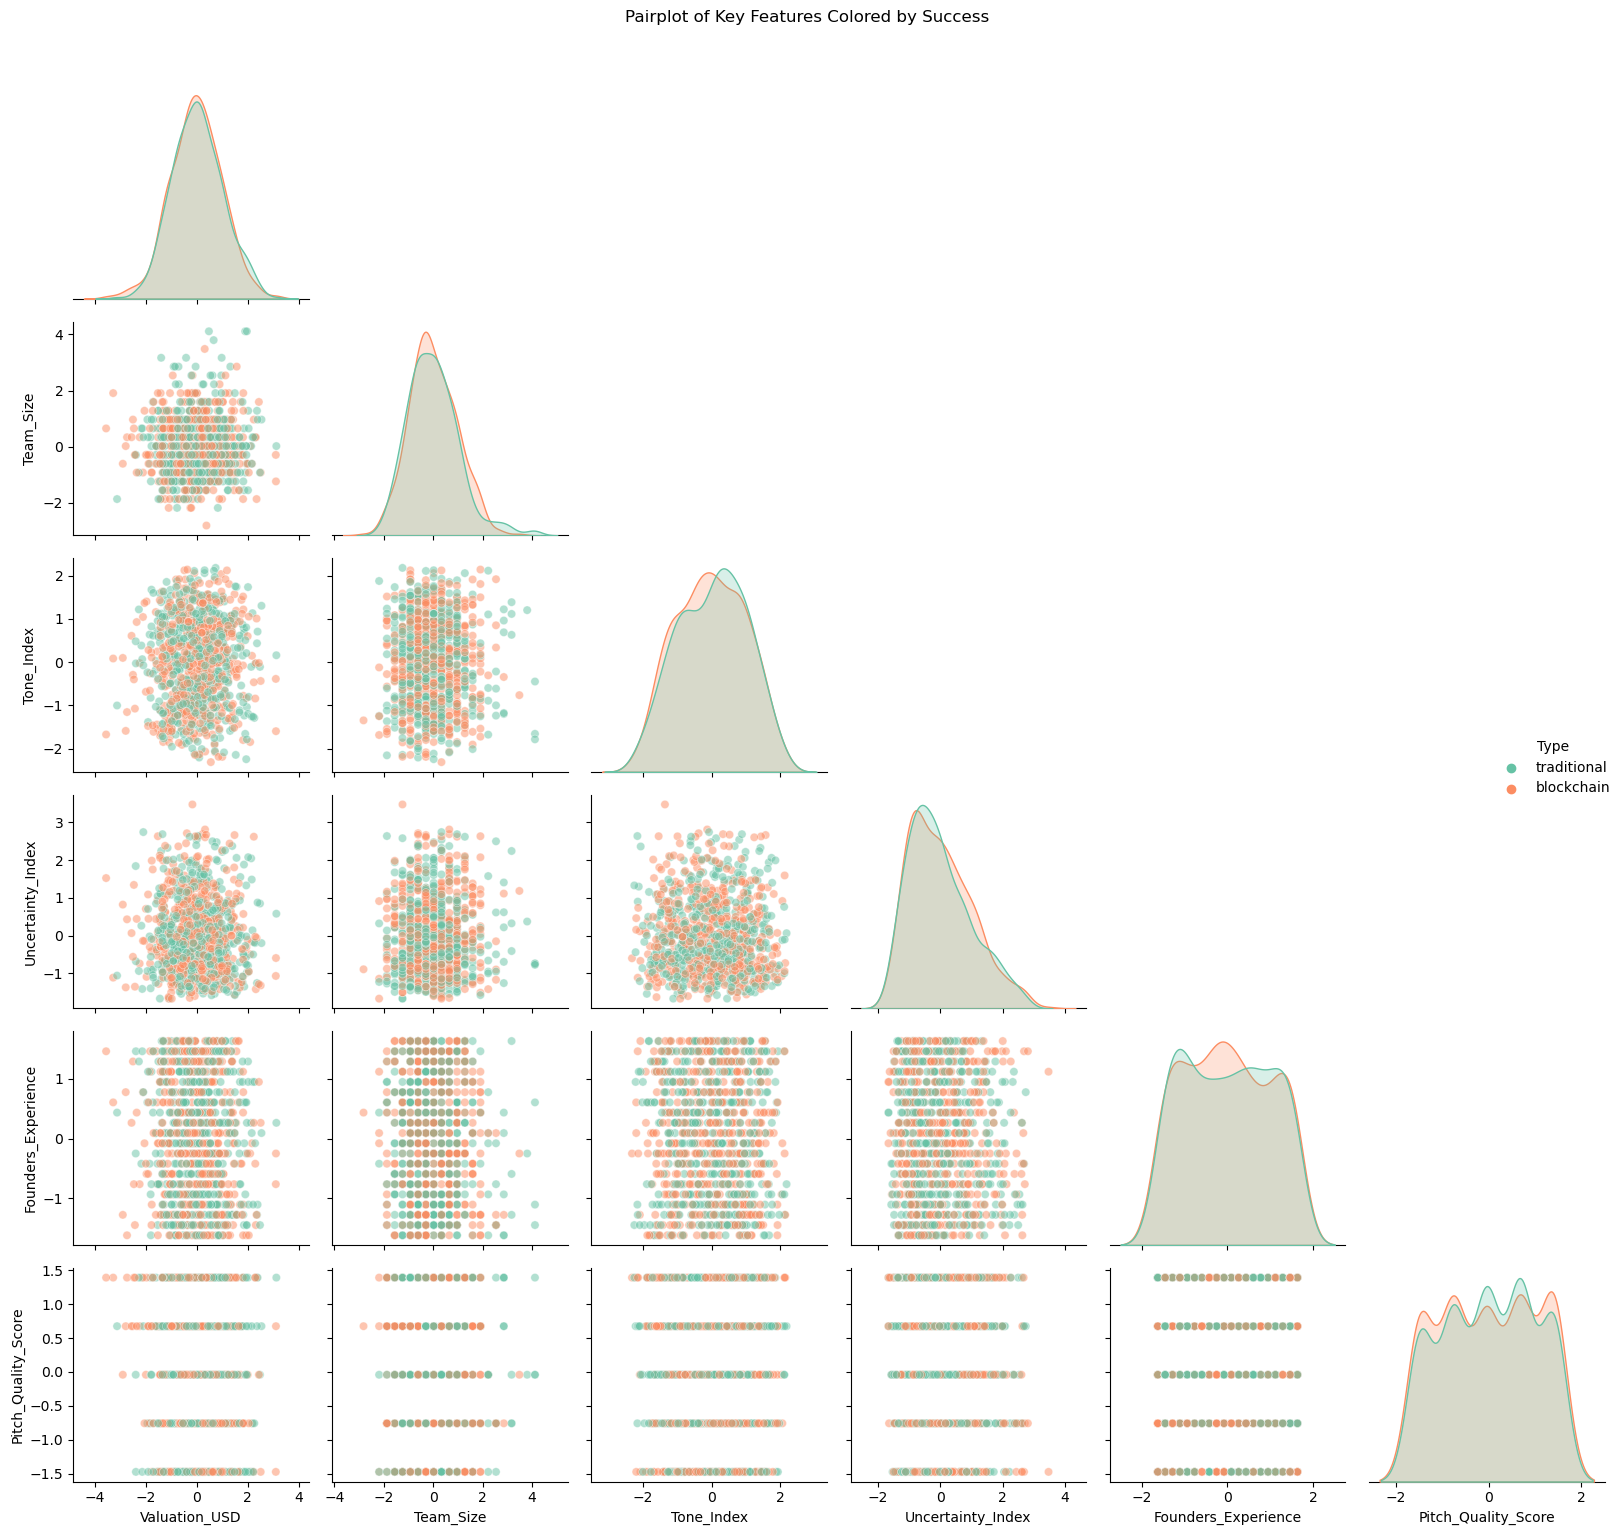

In [56]:
df['Success'] = df['Success'].astype(str)
sns.pairplot(
    df,
    vars=[
        'Valuation_USD', 'Team_Size', 'Tone_Index', 'Uncertainty_Index',
        'Founders_Experience', 'Pitch_Quality_Score'
    ],
    hue='Type',
    palette='Set2',
    diag_kind='kde',
    corner=True,
    plot_kws={'alpha': 0.5}
)
plt.suptitle("Pairplot of Key Features Colored by Success", y=1.02)
plt.tight_layout()
plt.show()

# LOWESS Regression

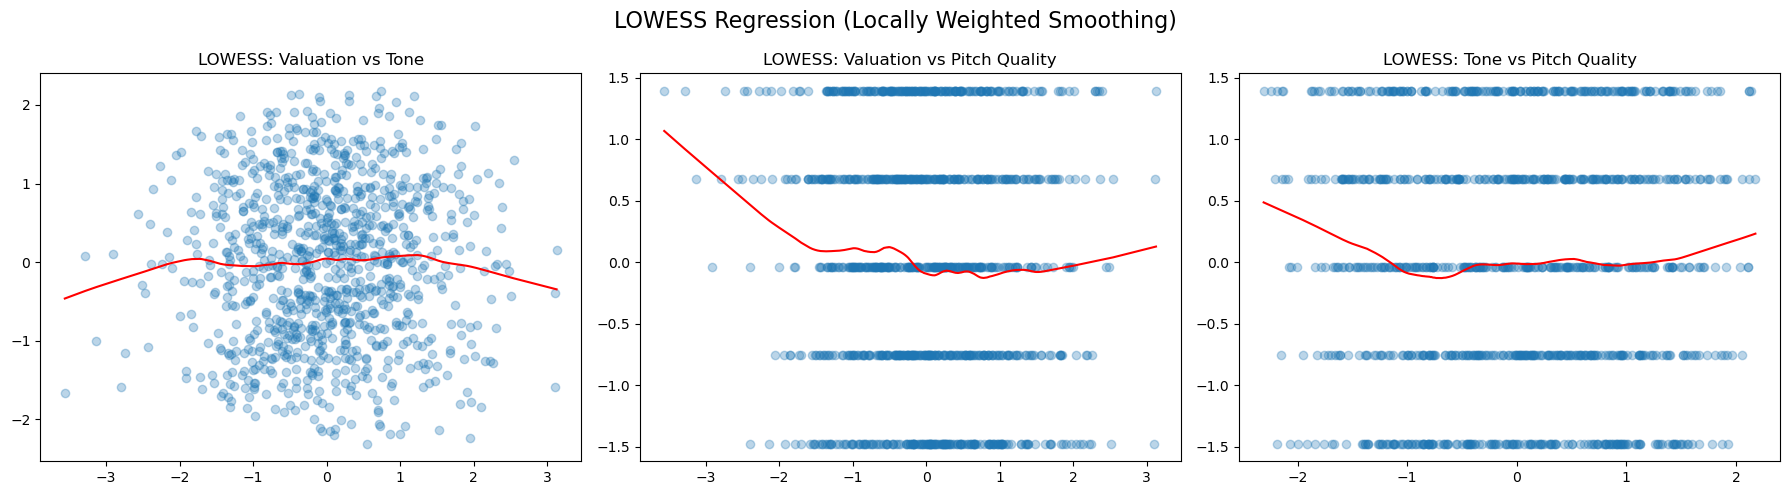

In [57]:
df_loess = df_interact.copy()

# Create LOWESS plots for selected relationships
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# 1. Valuation vs Tone
smoothed1 = lowess(df_loess['Tone_Index'], df_loess['Valuation_USD'], frac=0.3)
axs[0].scatter(df_loess['Valuation_USD'], df_loess['Tone_Index'], alpha=0.3)
axs[0].plot(smoothed1[:, 0], smoothed1[:, 1], color='red')
axs[0].set_title("LOWESS: Valuation vs Tone")

# 2. Valuation vs Pitch Quality
smoothed2 = lowess(df_loess['Pitch_Quality_Score'], df_loess['Valuation_USD'], frac=0.3)
axs[1].scatter(df_loess['Valuation_USD'], df_loess['Pitch_Quality_Score'], alpha=0.3)
axs[1].plot(smoothed2[:, 0], smoothed2[:, 1], color='red')
axs[1].set_title("LOWESS: Valuation vs Pitch Quality")

# 3. Tone vs Pitch Quality
smoothed3 = lowess(df_loess['Pitch_Quality_Score'], df_loess['Tone_Index'], frac=0.3)
axs[2].scatter(df_loess['Tone_Index'], df_loess['Pitch_Quality_Score'], alpha=0.3)
axs[2].plot(smoothed3[:, 0], smoothed3[:, 1], color='red')
axs[2].set_title("LOWESS: Tone vs Pitch Quality")

plt.suptitle("LOWESS Regression (Locally Weighted Smoothing)", fontsize=16)
plt.tight_layout()
plt.show()


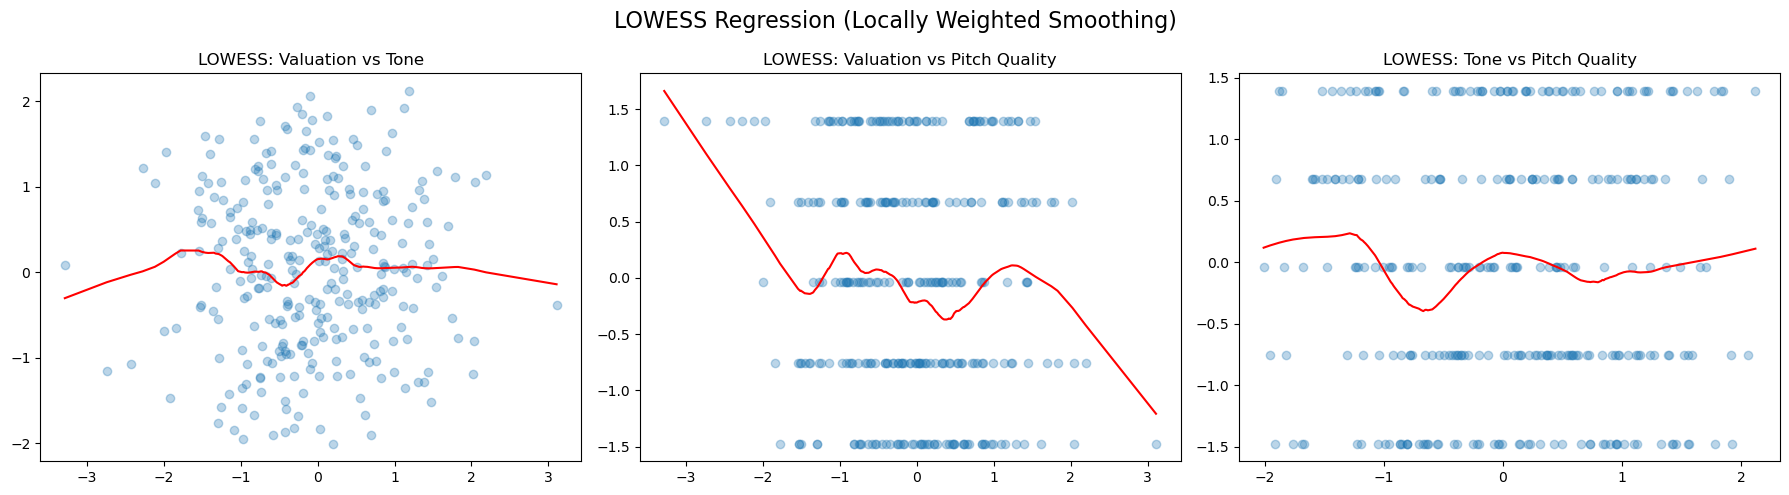

In [58]:
# Sample data to reduce memory usage
df_loess = df_interact.sample(n=300, random_state=42)

# Create LOWESS plots for selected relationships
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# 1. Valuation vs Tone
smoothed1 = lowess(df_loess['Tone_Index'], df_loess['Valuation_USD'], frac=0.3)
axs[0].scatter(df_loess['Valuation_USD'], df_loess['Tone_Index'], alpha=0.3)
axs[0].plot(smoothed1[:, 0], smoothed1[:, 1], color='red')
axs[0].set_title("LOWESS: Valuation vs Tone")

# 2. Valuation vs Pitch Quality
smoothed2 = lowess(df_loess['Pitch_Quality_Score'], df_loess['Valuation_USD'], frac=0.3)
axs[1].scatter(df_loess['Valuation_USD'], df_loess['Pitch_Quality_Score'], alpha=0.3)
axs[1].plot(smoothed2[:, 0], smoothed2[:, 1], color='red')
axs[1].set_title("LOWESS: Valuation vs Pitch Quality")

# 3. Tone vs Pitch Quality
smoothed3 = lowess(df_loess['Pitch_Quality_Score'], df_loess['Tone_Index'], frac=0.3)
axs[2].scatter(df_loess['Tone_Index'], df_loess['Pitch_Quality_Score'], alpha=0.3)
axs[2].plot(smoothed3[:, 0], smoothed3[:, 1], color='red')
axs[2].set_title("LOWESS: Tone vs Pitch Quality")

plt.suptitle("LOWESS Regression (Locally Weighted Smoothing)", fontsize=16)
plt.tight_layout()
plt.show()


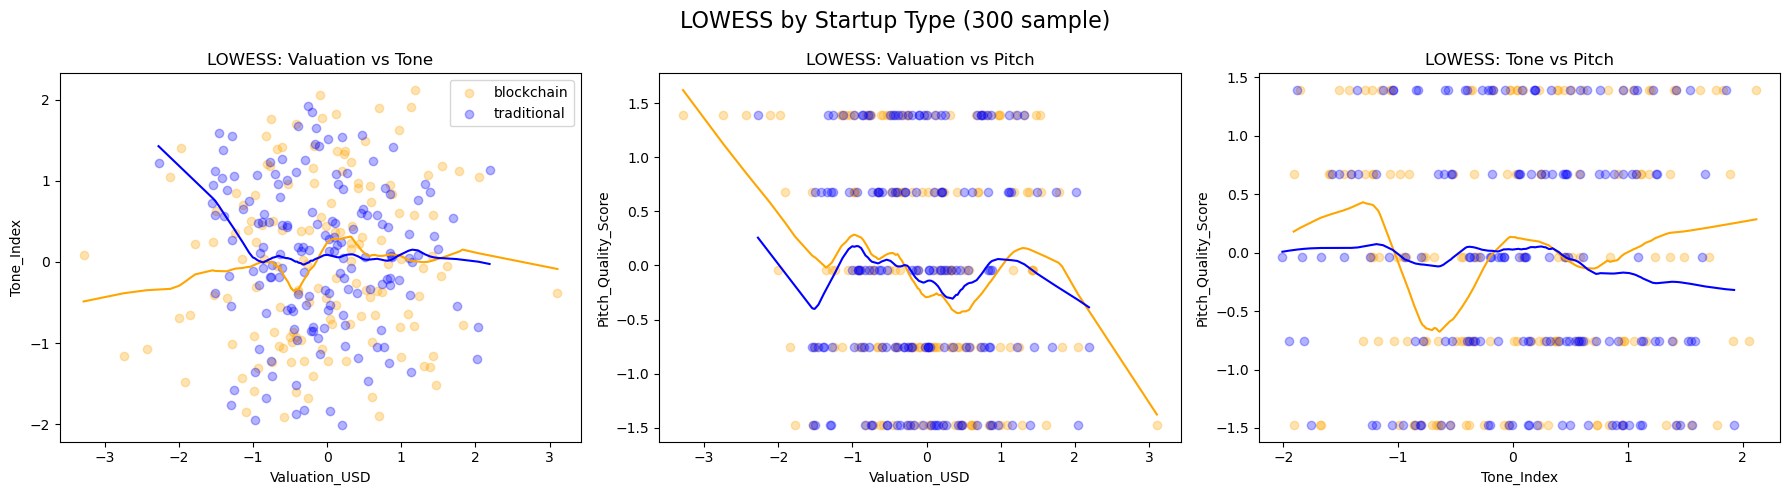

In [59]:
# LOWESS plots split by Type (blockchain vs traditional)
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

colors = {'blockchain': 'orange', 'traditional': 'blue'}
sampled_df = df_interact.sample(n=300, random_state=42)

for i, (x, y, title) in enumerate([
    ('Valuation_USD', 'Tone_Index', 'Valuation vs Tone'),
    ('Valuation_USD', 'Pitch_Quality_Score', 'Valuation vs Pitch'),
    ('Tone_Index', 'Pitch_Quality_Score', 'Tone vs Pitch')
]):
    for typ in ['blockchain', 'traditional']:
        sub = sampled_df[sampled_df['Type'] == typ]
        smoothed = lowess(sub[y], sub[x], frac=0.3)
        axs[i].scatter(sub[x], sub[y], alpha=0.3, label=f"{typ}", color=colors[typ])
        axs[i].plot(smoothed[:, 0], smoothed[:, 1], color=colors[typ])
        axs[i].set_title(f"LOWESS: {title}")
        axs[i].set_xlabel(x)
        axs[i].set_ylabel(y)

axs[0].legend()
plt.suptitle("LOWESS by Startup Type (300 sample)", fontsize=16)
plt.tight_layout()
plt.show()


# Pairplot

In [ ]:
sns.set_theme(style="ticks")
sns.pairplot(data, hue="Type",kind="kde")
plt.show()

In [ ]:
df['Success'] = df['Success'].astype(str)
sns.pairplot(
    df,
    vars=[
        'Valuation_USD', 'Team_Size', 'Tone_Index', 'Uncertainty_Index',
        'Founders_Experience', 'Pitch_Quality_Score'
    ],
    hue='Success',
    palette='Set2',
    diag_kind='kde',
    corner=True,
    plot_kws={'alpha': 0.5}
)
plt.suptitle("Pairplot of Key Features Colored by Success", y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
df_interact.to_excel('D:/final_blockchain_traditional/dataset_standard.xlsx')

### Pairplot of Key Features Colored by Success

The pairplot visualizes **bivariate relationships and marginal distributions** among key standardized features, with observations color-coded by **success status** (`1 = successful`, `0 = unsuccessful`).

#### 🔍 Diagonal Panels: Univariate Distributions
- **Successful startups (green)** tend to cluster toward the higher end of key features such as `Valuation_USD`, `Tone_Index`, and `Pitch_Quality_Score`.
- In contrast, **unsuccessful startups (salmon)** show broader or left-shifted distributions, particularly in `Uncertainty_Index`, where greater textual ambiguity is concentrated among failures.

#### 🔗 Off-Diagonal Panels: Feature Interactions
- **Valuation vs. Team Size**: A loose positive relationship is observable, with successful startups slightly more concentrated in higher-valued, larger teams.
- **Tone Index vs. Uncertainty Index**: As expected, these features are **inversely related**, and successful startups tend to occupy the region with **high tone and low uncertainty**.
- **Founders’ Experience** shows no strong linear relationship with other features, and the clustering of points suggests its impact is not easily separable in two-dimensional space.
- **Pitch_Quality_Score** appears discretized (as expected from rating scales), but successful startups are more concentrated in the upper score bins.

#### 🧠 Insights:
- The pairplot confirms that **combinations of financial, structural, and linguistic features** separate successful from unsuccessful startups in multi-dimensional space.
- However, many boundaries are non-linear or overlapping—justifying the use of **nonlinear models** such as **Random Forests** and **Logistic Regression with interaction terms** for predictive analysis.


# Conclusion: Insights from Logistic Regression Interaction Effects

The inclusion of interaction terms in the logistic regression model allowed us to assess whether the effects of key predictors on startup success differ systematically between **blockchain startups** and **traditional IT firms**. The analysis yields several important conclusions:

#### 1. **Predictor Effects Are Context-Dependent**
The significance and magnitude of several predictors vary depending on the **technological nature** of the startup:
- **Valuation** has a stronger marginal effect on success for **traditional startups**, where capital accumulation often signals investor trust and operational readiness.
- For **blockchain startups**, success probabilities reach high levels even at moderate valuations, possibly due to speculative dynamics and token-based financing.

#### 2. **Founders’ Experience Plays a Divergent Role**
- Among blockchain startups, **minimal founder experience** is sufficient to achieve high success probabilities—possibly reflecting the disruptive, rapidly evolving nature of the blockchain space where institutional experience is less valued.
- In contrast, **traditional startups** exhibit a negative association between founder experience and success, perhaps indicating rigidity, misalignment with innovation cycles, or higher risk aversion.

#### 3. **Technical Transparency Matters More in Blockchain**
- **GitHub presence** significantly increases the probability of success in blockchain startups, highlighting the role of **open-source validation**, developer engagement, and code transparency.
- This effect is far less pronounced in traditional startups, where proprietary development and institutional networks often compensate for public transparency.

#### 4. **Pitch Quality and KPI Sharing Show Subtle but Consistent Effects**
- **Pitch quality** improves success probability for both startup types, but the interaction effect suggests a **slightly higher return** on polished presentations in blockchain contexts, where remote communication dominates.
- **Sharing KPIs** has a **positive but modest effect** across both groups, reinforcing the general value of performance transparency, though not a decisive factor alone.

---

**Overall Implication:**  
The interaction analysis confirms that **traditional valuation frameworks**—focused solely on financial indicators—are insufficient in capturing success dynamics in the digital economy. Instead, success in modern startup ecosystems is shaped by a **blend of financial, behavioral, and communicative signals**, whose influence varies by technological domain. This supports the second hypothesis (H2) and highlights the need for **context-aware evaluation models** in startup analytics.
